
# Critical renewable-resource year — Magallanes, site-based analysis (2016–2025)

This notebook compares `magallanes_2016.nc` to `magallanes_2025.nc` to identify the most critical weather year in terms of consecutive days with low renewable potential.

Main update relative to the previous version:

- The **year-to-year comparison** is based on a **single representative site** (`MAIN_SITE`, default: `cabo_negro`) instead of a spatial/system average.
- A separate **spatial comparison** is then performed for selected strategic locations during the selected critical year.
- Daily wind and solar capacity factors are classified into four categories:
  - **Both high**
  - **Wind low / Solar high**
  - **Solar low / Wind high**
  - **Both low**

The main criticality metric is the longest consecutive run of **both-low** days at the main site.


In [2]:

# Imports and configuration
import importlib
from pathlib import Path
import calendar
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

import config
config = importlib.reload(config)

# ── Case setup ───────────────────────────────────────────────────────────────
CASE_FOLDER = "input_punta_arenas"
CASE_NAME = "magallanes"
YEARS = list(range(2016, 2026))

DATA_DIR = Path("data")
OUTPUT_DIR = Path("output_critical_weather_year")
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# VRE assumptions: keep consistent with your cutout / case analysis notebooks
VRE_METHOD = "atlite_technology"
WIND_TURBINE = "Vestas_V112_3MW"
SOLAR_PANEL = "CSi"
SOLAR_ORIENTATION = "latitude_optimal"

# Same grid-lock setup used when the cutouts were created
DX = 0.25
DY = 0.25
GRID_LOCK_MODE = "fixed_bounds"
FIXED_BOUNDS = (-76.0, -66.0, -56.0, -50.0)  # Full Magallanes
REFERENCE_YEAR_FOR_GRID = 2019

# ── Analysis setup ───────────────────────────────────────────────────────────
# Main site used to select the critical weather year.
# The spatial comparison below can include more sites, but the year ranking should
# use only one representative site to avoid smoothing low-resource events.
MAIN_SITE = "cabo_negro"

# Approximate coordinates. Edit these if you want to use project-specific points.
# Important: at ERA5 0.25°, several nearby locations may fall in the same grid cell.
SITES = {
    # Main industrial/demand area near Punta Arenas
    "cabo_negro":      {"lat": -52.966, "lon": -70.829},
    "punta_arenas":    {"lat": -53.163, "lon": -70.917},

    # Strategic sites around the Strait / wider Magallanes region
    "san_gregorio":    {"lat": -52.617, "lon": -69.633},
    "rio_verde":       {"lat": -52.650, "lon": -71.483},
    "villa_tehuelches": {"lat": -52.420, "lon": -71.400},
    "punta_delgada":   {"lat": -52.450, "lon": -69.550},
}

# Low-resource thresholds used for daily classification.
# Keep these simple and explicit for the paper; run the sensitivity section if needed.
LOW_WIND_THRESHOLD = 0.20
LOW_SOLAR_THRESHOLD = 0.12

# Plot controls
PLOT_EACH_YEAR = True          # scatter + monthly strip for all years at MAIN_SITE
PLOT_TOP_N_YEARS = 3           # additional focus plots for top-ranked years; set 0 to skip
PLOT_SPATIAL_COMPARISON = True # spatial comparison for the selected critical year

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

print(f"Case: {CASE_NAME}")
print(f"Years: {YEARS[0]}-{YEARS[-1]}")
print(f"Main site for year ranking: {MAIN_SITE}")
print(f"Wind threshold: {LOW_WIND_THRESHOLD:.2f}")
print(f"Solar threshold: {LOW_SOLAR_THRESHOLD:.2f}")
print(f"Outputs: {OUTPUT_DIR}")


Case: magallanes
Years: 2016-2025
Main site for year ranking: cabo_negro
Wind threshold: 0.20
Solar threshold: 0.12
Outputs: output_critical_weather_year


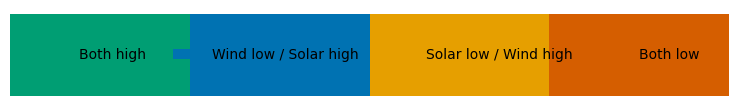

In [3]:

# Colorblind-friendly palette used for the classification plots
# Okabe-Ito palette: widely used colorblind-safe qualitative palette.

OKABE_ITO = {
    "orange": "#E69F00",
    "sky_blue": "#56B4E9",
    "bluish_green": "#009E73",
    "yellow": "#F0E442",
    "blue": "#0072B2",
    "vermillion": "#D55E00",
    "reddish_purple": "#CC79A7",
    "black": "#000000",
}

category_order = [
    "both_high",
    "wind_low_solar_high",
    "solar_low_wind_high",
    "both_low",
]

category_labels = {
    "both_high": "Both high",
    "wind_low_solar_high": "Wind low / Solar high",
    "solar_low_wind_high": "Solar low / Wind high",
    "both_low": "Both low",
}

category_colors = {
    "both_high": OKABE_ITO["bluish_green"],       # green
    "wind_low_solar_high": OKABE_ITO["blue"],    # blue
    "solar_low_wind_high": OKABE_ITO["orange"],  # orange
    "both_low": OKABE_ITO["vermillion"],         # red-orange
}

tech_colors = {
    "wind": OKABE_ITO["blue"],
    "solar": OKABE_ITO["orange"],
    "threshold": OKABE_ITO["black"],
}

# Quick visual check
fig, ax = plt.subplots(figsize=(8, 1.2))
for i, category in enumerate(category_order):
    ax.barh([0], [1], left=[i], color=category_colors[category], label=category_labels[category])
ax.set_xlim(0, len(category_order))
ax.set_yticks([])
ax.set_xticks([])
ax.legend(ncol=4, loc="center", frameon=False)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()


In [4]:

# Load nodes and define site dataframe
import xarray as xr

paths = config.get_case_paths(CASE_FOLDER)
nodes_df = config.load_nodes_from_csv(paths["csv_nodes"])

if nodes_df is None or nodes_df.empty:
    raise ValueError("Nodes CSV is empty or missing.")
if not {"lat", "lon"}.issubset(nodes_df.columns):
    raise ValueError("Nodes CSV must include lat and lon columns.")

valid_coords = nodes_df[["lat", "lon"]].dropna()
if valid_coords.empty:
    raise ValueError("No valid lat/lon coordinates found in nodes CSV.")

# Site dataframe used by config.get_vre_profiles_from_cutout.
# It mimics the node table but contains selected strategic locations.
sites_df = pd.DataFrame(
    [{"zone": name, "lat": spec["lat"], "lon": spec["lon"]} for name, spec in SITES.items()]
)

if MAIN_SITE not in set(sites_df["zone"]):
    raise ValueError(f"MAIN_SITE={MAIN_SITE!r} not found in SITES keys: {list(SITES)}")

padding_deg = 1.0
derived_bounds = (
    float(valid_coords["lon"].min()) - padding_deg,
    float(valid_coords["lon"].max()) + padding_deg,
    float(valid_coords["lat"].min()) - padding_deg,
    float(valid_coords["lat"].max()) + padding_deg,
)

if GRID_LOCK_MODE == "fixed_bounds":
    lock_bounds = tuple(float(v) for v in FIXED_BOUNDS)
    lock_dx = float(DX)
    lock_dy = float(DY)
elif GRID_LOCK_MODE == "match_existing_year":
    ref_path = DATA_DIR / f"{CASE_NAME}_{REFERENCE_YEAR_FOR_GRID}.nc"
    if not ref_path.exists():
        raise FileNotFoundError(f"Reference cutout not found: {ref_path}")
    with xr.open_dataset(ref_path) as ds_ref:
        x_vals = np.array(ds_ref["x"].values)
        y_vals = np.array(ds_ref["y"].values)
        lock_bounds = (
            float(np.min(x_vals)),
            float(np.max(x_vals)),
            float(np.min(y_vals)),
            float(np.max(y_vals)),
        )
        lock_dx = float(np.median(np.diff(np.sort(np.unique(x_vals)))))
        lock_dy = float(np.median(np.diff(np.sort(np.unique(y_vals)))))
else:
    lock_bounds = derived_bounds
    lock_dx = float(DX)
    lock_dy = float(DY)

print("Original model nodes:")
display(nodes_df[["zone", "lat", "lon"]])

print("\nStrategic sites used in this notebook:")
display(sites_df)

print("\nCanonical grid:")
print(f"bounds={lock_bounds}")
print(f"dx={lock_dx}, dy={lock_dy}")


Original model nodes:


,zone,lat,lon
0,punta_arenas_1,-53.16,-70.93
1,punta_arenas_2,-53.16,-70.89



Strategic sites used in this notebook:


,zone,lat,lon
0,cabo_negro,-52.966,-70.829
1,punta_arenas,-53.163,-70.917
2,san_gregorio,-52.617,-69.633
3,rio_verde,-52.650,-71.483
4,villa_tehuelches,-52.420,-71.400
5,punta_delgada,-52.450,-69.550



Canonical grid:
bounds=(-76.0, -66.0, -56.0, -50.0)
dx=0.25, dy=0.25


In [5]:

# Check which ERA5 grid cell each strategic site maps to
# This is useful because points that are too close may fall in the same 0.25° cell.

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2) ** 2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c


def nearest_grid_cell_for_site(ds, lat, lon):
    x_vals = np.asarray(ds["x"].values, dtype=float)
    y_vals = np.asarray(ds["y"].values, dtype=float)
    nearest_lon = float(x_vals[np.argmin(np.abs(x_vals - lon))])
    nearest_lat = float(y_vals[np.argmin(np.abs(y_vals - lat))])
    dist_km = haversine_km(lat, lon, nearest_lat, nearest_lon)
    return nearest_lat, nearest_lon, dist_km

# Use the first available cutout to map sites to cells
first_existing_cutout = None
for y in YEARS:
    p = DATA_DIR / f"{CASE_NAME}_{y}.nc"
    if p.exists():
        first_existing_cutout = p
        break

if first_existing_cutout is None:
    raise FileNotFoundError(f"No cutout files found in {DATA_DIR} for {CASE_NAME}_YYYY.nc")

cell_rows = []
with xr.open_dataset(first_existing_cutout) as ds:
    for _, row in sites_df.iterrows():
        grid_lat, grid_lon, dist_km = nearest_grid_cell_for_site(ds, row["lat"], row["lon"])
        cell_rows.append({
            "site": row["zone"],
            "site_lat": row["lat"],
            "site_lon": row["lon"],
            "era5_grid_lat": grid_lat,
            "era5_grid_lon": grid_lon,
            "distance_to_grid_cell_km": dist_km,
            "grid_cell_id": f"{grid_lat:.3f}_{grid_lon:.3f}",
        })

site_grid_df = pd.DataFrame(cell_rows)
site_grid_csv = TABLES_DIR / f"{CASE_NAME}_strategic_sites_era5_grid_cells.csv"
site_grid_df.to_csv(site_grid_csv, index=False)

print(f"Grid-cell mapping based on: {first_existing_cutout}")
print(f"Saved: {site_grid_csv}")
display(site_grid_df)

# Warn if multiple sites map to the same grid cell
same_cell = site_grid_df.groupby("grid_cell_id")["site"].apply(list).reset_index()
duplicated_cells = same_cell[same_cell["site"].apply(len) > 1]
if not duplicated_cells.empty:
    print("\nWARNING: Some sites fall in the same ERA5 grid cell. Treat them as the same resource point:")
    display(duplicated_cells)


Grid-cell mapping based on: data\magallanes_2016.nc
Saved: output_critical_weather_year\tables\magallanes_strategic_sites_era5_grid_cells.csv


,site,site_lat,site_lon,era5_grid_lat,era5_grid_lon,distance_to_grid_cell_km,grid_cell_id
0,cabo_negro,-52.966,-70.829,-53.00,-70.75,6.501008,-53.000_-70.750
1,punta_arenas,-53.163,-70.917,-53.25,-71.00,11.141833,-53.250_-71.000
2,san_gregorio,-52.617,-69.633,-52.50,-69.75,15.225385,-52.500_-69.750
3,rio_verde,-52.650,-71.483,-52.75,-71.50,11.178341,-52.750_-71.500
4,villa_tehuelches,-52.420,-71.400,-52.50,-71.50,11.181945,-52.500_-71.500
5,punta_delgada,-52.450,-69.550,-52.50,-69.50,6.509919,-52.500_-69.500


In [6]:

# Helper functions

def savefig(fig, filename, dpi=300):
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {path}")


def longest_true_run(mask_array: np.ndarray) -> int:
    max_run = 0
    run = 0
    for value in np.asarray(mask_array).astype(bool):
        if value:
            run += 1
            max_run = max(max_run, run)
        else:
            run = 0
    return int(max_run)


def longest_true_run_dates(mask_series: pd.Series):
    s = mask_series.astype(bool).dropna()
    if s.empty or not s.any():
        return 0, pd.NaT, pd.NaT

    best_len = 0
    best_start = None
    best_end = None
    current_len = 0
    current_start = None

    for timestamp, value in s.items():
        if value:
            if current_len == 0:
                current_start = timestamp
            current_len += 1
            if current_len > best_len:
                best_len = current_len
                best_start = current_start
                best_end = timestamp
        else:
            current_len = 0
            current_start = None

    return int(best_len), best_start, best_end


def classify_wind_solar_days(df: pd.DataFrame,
                             wind_threshold: float,
                             solar_threshold: float) -> pd.DataFrame:
    out = df.copy()
    out["wind_low"] = out["wind_cf"] < wind_threshold
    out["solar_low"] = out["solar_cf"] < solar_threshold
    out["both_low"] = out["wind_low"] & out["solar_low"]

    out["category"] = np.select(
        [
            out["both_low"],
            out["wind_low"] & ~out["solar_low"],
            ~out["wind_low"] & out["solar_low"],
        ],
        ["both_low", "wind_low_solar_high", "solar_low_wind_high"],
        default="both_high",
    )
    return out


def compute_metrics(classified_df: pd.DataFrame, year: int, site: str) -> dict:
    both_len, both_start, both_end = longest_true_run_dates(classified_df["both_low"])
    wind_len, wind_start, wind_end = longest_true_run_dates(classified_df["wind_low"])
    solar_len, solar_start, solar_end = longest_true_run_dates(classified_df["solar_low"])

    monthly_both_runs = []
    monthly_both_days = []
    for m in range(1, 13):
        m_df = classified_df[classified_df.index.month == m]
        if m_df.empty:
            monthly_both_runs.append(0)
            monthly_both_days.append(0)
        else:
            monthly_both_runs.append(longest_true_run(m_df["both_low"].to_numpy()))
            monthly_both_days.append(int(m_df["both_low"].sum()))

    category_counts = classified_df["category"].value_counts().reindex(category_order, fill_value=0)

    return {
        "site": site,
        "year": int(year),
        "days": int(len(classified_df)),
        "wind_cf_mean": float(classified_df["wind_cf"].mean()),
        "solar_cf_mean": float(classified_df["solar_cf"].mean()),
        "both_low_days": int(category_counts["both_low"]),
        "wind_low_solar_high_days": int(category_counts["wind_low_solar_high"]),
        "solar_low_wind_high_days": int(category_counts["solar_low_wind_high"]),
        "both_high_days": int(category_counts["both_high"]),
        "both_low_share": float(category_counts["both_low"] / len(classified_df)),
        "max_consecutive_both_low_days": both_len,
        "max_both_low_start": both_start.strftime("%Y-%m-%d") if pd.notna(both_start) else "",
        "max_both_low_end": both_end.strftime("%Y-%m-%d") if pd.notna(both_end) else "",
        "max_consecutive_wind_low_days": wind_len,
        "max_wind_low_start": wind_start.strftime("%Y-%m-%d") if pd.notna(wind_start) else "",
        "max_wind_low_end": wind_end.strftime("%Y-%m-%d") if pd.notna(wind_end) else "",
        "max_consecutive_solar_low_days": solar_len,
        "max_solar_low_start": solar_start.strftime("%Y-%m-%d") if pd.notna(solar_start) else "",
        "max_solar_low_end": solar_end.strftime("%Y-%m-%d") if pd.notna(solar_end) else "",
        "worst_month_both_low_run": int(max(monthly_both_runs)),
        "worst_month_both_low_days": int(max(monthly_both_days)),
        "worst_month_by_run": month_labels[int(np.argmax(monthly_both_runs))],
        "worst_month_by_days": month_labels[int(np.argmax(monthly_both_days))],
    }


def prepare_daily_site_df(wind_cf: pd.DataFrame, solar_cf: pd.DataFrame, year: int) -> pd.DataFrame:
    rows = []
    for site in wind_cf.columns:
        daily = pd.DataFrame({
            "wind_cf": wind_cf[site].resample("D").mean(),
            "solar_cf": solar_cf[site].resample("D").mean(),
        }).dropna()
        daily = classify_wind_solar_days(daily, LOW_WIND_THRESHOLD, LOW_SOLAR_THRESHOLD)
        daily["year"] = int(year)
        daily["site"] = site
        daily["month"] = daily.index.month
        daily["day"] = daily.index.day
        daily["dayofyear"] = daily.index.dayofyear
        rows.append(daily)
    return pd.concat(rows).sort_index()


def plot_scatter(df, title, filename_prefix, x_label_site=True):
    fig, ax = plt.subplots(figsize=(12, 5.8))

    for category in category_order:
        subset = df[df["category"] == category]
        if subset.empty:
            continue
        ax.scatter(
            subset["wind_cf"],
            subset["solar_cf"],
            s=26,
            alpha=0.85,
            color=category_colors[category],
            label=category_labels[category],
        )

    ax.axvline(LOW_WIND_THRESHOLD, color="black", linestyle="--", linewidth=1.0)
    ax.axhline(LOW_SOLAR_THRESHOLD, color="black", linestyle="--", linewidth=1.0)
    ax.set_xlabel("Daily mean wind capacity factor [-]")
    ax.set_ylabel("Daily mean solar capacity factor [-]")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best", fontsize=8)
    plt.tight_layout()
    savefig(fig, f"{filename_prefix}_wind_vs_solar_daily_scatter.png")
    plt.show()


def plot_monthly_strip(calendar_df, year, title, filename_prefix):
    fig, ax = plt.subplots(figsize=(12, 6.2))
    row_height = 0.66
    month_sequence = list(range(1, 13))
    y_positions = {month: len(month_sequence) - idx for idx, month in enumerate(month_sequence)}

    x_left, x_right = 0.0, 1.0
    total_row_width = x_right - x_left

    for month in month_sequence:
        y = y_positions[month]
        n_days = calendar.monthrange(int(year), month)[1]
        day_width = total_row_width / n_days
        gap = day_width * 0.08

        month_data = calendar_df[calendar_df["month"] == month]
        for _, row in month_data.iterrows():
            d = int(row["day"])
            x0 = x_left + (d - 1) * day_width + gap / 2
            rect = Rectangle(
                (x0, y - row_height / 2),
                day_width - gap,
                row_height,
                facecolor=category_colors[row["category"]],
                edgecolor="white",
                linewidth=0.6,
            )
            ax.add_patch(rect)

    ax.set_xlim(x_left, x_right)
    ax.set_ylim(0.35, len(month_sequence) + 0.9)
    ax.set_yticks([y_positions[m] for m in month_sequence])
    ax.set_yticklabels(month_labels, fontsize=14)
    ax.set_xticks([])
    ax.set_title(title, pad=42)
    for side in ["top", "right", "left", "bottom"]:
        ax.spines[side].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", length=0)

    legend_handles = [
        Patch(facecolor=category_colors[category], edgecolor="none", label=category_labels[category])
        for category in category_order
        if (calendar_df["category"] == category).any()
    ]
    ax.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=4,
        frameon=False,
        fontsize=12,
        handlelength=1.2,
        handleheight=1.2,
        columnspacing=1.8,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    savefig(fig, f"{filename_prefix}_monthly_daily_category_strip.png")
    plt.show()


In [7]:

# Compute daily wind/solar CF for all strategic sites and years
# The year ranking below will use only MAIN_SITE, but this table is useful for spatial comparisons.

all_daily_sites = []
missing_years = []

for year in YEARS:
    cutout_file = DATA_DIR / f"{CASE_NAME}_{year}.nc"
    if not cutout_file.exists():
        print(f"Missing cutout for {year}: {cutout_file}")
        missing_years.append(year)
        continue

    print(f"Processing {year}...")
    cutout = config.get_case_cutout(
        year=year,
        force_prepare=False,
        base_dir="data",
        case_name=CASE_NAME,
        bounds=lock_bounds,
        nodes_df=sites_df,
        dx=lock_dx,
        dy=lock_dy,
    )

    wind_cf, solar_cf = config.get_vre_profiles_from_cutout(
        cutout=cutout,
        nodes_df=sites_df,
        method=VRE_METHOD,
        wind_turbine=WIND_TURBINE,
        solar_panel=SOLAR_PANEL,
        solar_orientation=SOLAR_ORIENTATION,
    )

    # Ensure site columns are strings and consistent
    wind_cf.columns = wind_cf.columns.astype(str)
    solar_cf.columns = solar_cf.columns.astype(str)

    daily_sites = prepare_daily_site_df(wind_cf, solar_cf, year)
    all_daily_sites.append(daily_sites)

if not all_daily_sites:
    raise RuntimeError("No valid cutouts found. Check DATA_DIR, CASE_NAME, and year file names.")

daily_sites_df = pd.concat(all_daily_sites).sort_values(["site", "year"])
daily_sites_csv = TABLES_DIR / f"{CASE_NAME}_daily_wind_solar_categories_by_site_2016_2025.csv"
daily_sites_df.to_csv(daily_sites_csv)

print(f"Saved: {daily_sites_csv}")
if missing_years:
    print(f"Missing years skipped: {missing_years}")

display(daily_sites_df.head())


Processing 2016...


c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\cutout.py:156: UserWarning:

Arguments module, x, y, time, dx, dy are ignored, since cutout is already built.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbin

Processing 2017...


c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\cutout.py:156: UserWarning:

Arguments module, x, y, time, dx, dy are ignored, since cutout is already built.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbin

Processing 2018...


...

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\cutout.py:156: UserWarning:

Arguments module, x, y, time, dx, dy are ignored, since cutout is already built.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbin

Processing 2025...


c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\cutout.py:156: UserWarning:

Arguments module, x, y, time, dx, dy are ignored, since cutout is already built.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbin

Saved: output_critical_weather_year\tables\magallanes_daily_wind_solar_categories_by_site_2016_2025.csv


,wind_cf,solar_cf,wind_low,solar_low,both_low,category,year,site,month,day,dayofyear
2016-01-01,0.027206,0.244161,True,False,False,wind_low_solar_high,2016,cabo_negro,1,1,1
2016-01-02,0.649592,0.213913,False,False,False,both_high,2016,cabo_negro,1,2,2
2016-01-03,0.716120,0.198517,False,False,False,both_high,2016,cabo_negro,1,3,3
2016-01-04,0.555554,0.128575,False,False,False,both_high,2016,cabo_negro,1,4,4
2016-01-05,0.998730,0.168627,False,False,False,both_high,2016,cabo_negro,1,5,5


In [8]:

# Main analysis: compare years at one representative site
main_daily_df = daily_sites_df[daily_sites_df["site"] == MAIN_SITE].copy()
if main_daily_df.empty:
    raise RuntimeError(f"No daily data found for MAIN_SITE={MAIN_SITE}")

summary_rows = []
for year, group in main_daily_df.groupby("year"):
    summary_rows.append(compute_metrics(group, int(year), MAIN_SITE))

summary_df = pd.DataFrame(summary_rows).sort_values(
    ["max_consecutive_both_low_days", "both_low_days", "max_consecutive_wind_low_days"],
    ascending=[False, False, False],
).reset_index(drop=True)
summary_df.insert(0, "rank", np.arange(1, len(summary_df) + 1))

critical_year = int(summary_df.loc[0, "year"])
critical_start = summary_df.loc[0, "max_both_low_start"]
critical_end = summary_df.loc[0, "max_both_low_end"]

summary_csv = TABLES_DIR / f"{CASE_NAME}_{MAIN_SITE}_critical_weather_year_summary_2016_2025.csv"
main_daily_csv = TABLES_DIR / f"{CASE_NAME}_{MAIN_SITE}_daily_wind_solar_categories_2016_2025.csv"
summary_df.to_csv(summary_csv, index=False)
main_daily_df.to_csv(main_daily_csv)

print(f"Saved: {summary_csv}")
print(f"Saved: {main_daily_csv}")
print(f"\nSelected critical year at {MAIN_SITE}: {critical_year}")
print(f"Longest both-low sequence: {summary_df.loc[0, 'max_consecutive_both_low_days']} days ({critical_start} to {critical_end})")

display(summary_df)


Saved: output_critical_weather_year\tables\magallanes_cabo_negro_critical_weather_year_summary_2016_2025.csv
Saved: output_critical_weather_year\tables\magallanes_cabo_negro_daily_wind_solar_categories_2016_2025.csv

Selected critical year at cabo_negro: 2020
Longest both-low sequence: 9 days (2020-06-28 to 2020-07-06)


,rank,site,year,days,wind_cf_mean,solar_cf_mean,both_low_days,wind_low_solar_high_days,solar_low_wind_high_days,both_high_days,...,max_consecutive_wind_low_days,max_wind_low_start,max_wind_low_end,max_consecutive_solar_low_days,max_solar_low_start,max_solar_low_end,worst_month_both_low_run,worst_month_both_low_days,worst_month_by_run,worst_month_by_days
0,1,cabo_negro,2020,366,0.576391,0.122746,44,22,147,153,...,9,2020-06-28,2020-07-06,62,2020-05-20,2020-07-20,6,12,Jul,Jul
1,2,cabo_negro,2016,366,0.554993,0.133308,48,24,125,169,...,8,2016-07-29,2016-08-05,49,2016-05-27,2016-07-14,6,16,Jul,May
2,3,cabo_negro,2025,365,0.599775,0.132440,36,25,127,177,...,8,2025-07-26,2025-08-02,57,2025-05-24,2025-07-19,6,8,Jun,Jun
3,4,cabo_negro,2018,365,0.583196,0.131558,32,29,142,162,...,12,2018-09-18,2018-09-29,51,2018-05-28,2018-07-17,6,10,Jun,Jul
4,5,cabo_negro,2024,366,0.588746,0.126300,46,20,137,163,...,5,2024-05-06,2024-05-10,57,2024-05-27,2024-07-22,5,18,May,Jun
5,6,cabo_negro,2019,365,0.607227,0.130868,27,23,133,182,...,5,2019-07-07,2019-07-11,68,2019-05-14,2019-07-20,5,10,Jul,Jul
6,7,cabo_negro,2021,365,0.609905,0.129196,35,21,149,160,...,4,2021-07-14,2021-07-17,60,2021-05-14,2021-07-12,4,8,Jul,Jun
7,8,cabo_negro,2022,365,0.607838,0.132339,30,20,144,171,...,4,2022-07-03,2022-07-06,47,2022-05-23,2022-07-08,4,9,Jul,Jul
8,9,cabo_negro,2017,365,0.604786,0.129612,29,26,157,153,...,8,2017-03-27,2017-04-03,64,2017-05-21,2017-07-23,3,7,Mar,May
9,10,cabo_negro,2023,365,0.644045,0.134559,18,12,146,189,...,3,2023-06-20,2023-06-22,52,2023-05-23,2023-07-13,3,6,Jun,Jun


Saved: output_critical_weather_year\figures\magallanes_cabo_negro_criticality_ranking_both_low_streak_2016_2025.png


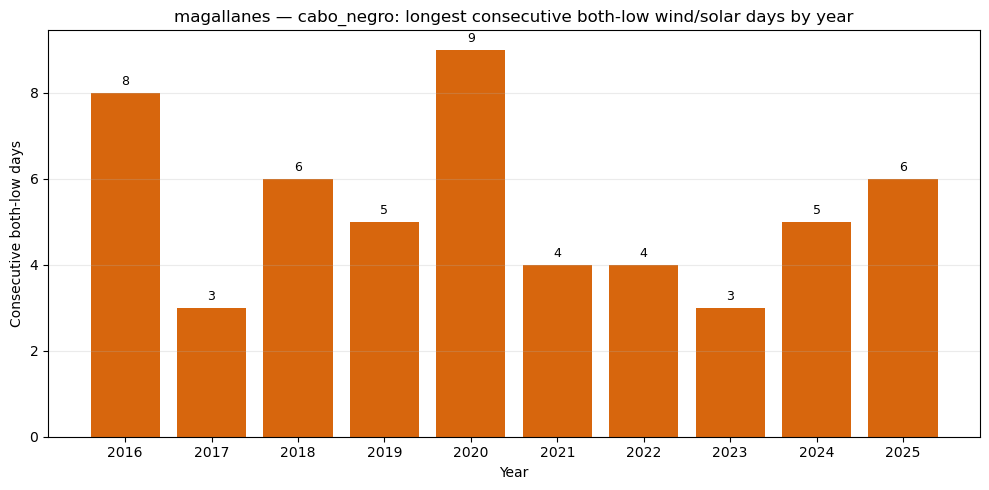

In [9]:

# Plot 1: criticality ranking across years at MAIN_SITE
plot_df = summary_df.sort_values("year")

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    plot_df["year"].astype(str),
    plot_df["max_consecutive_both_low_days"],
    color=category_colors["both_low"],
    alpha=0.95,
)
ax.set_title(f"{CASE_NAME} — {MAIN_SITE}: longest consecutive both-low wind/solar days by year")
ax.set_xlabel("Year")
ax.set_ylabel("Consecutive both-low days")
ax.grid(True, axis="y", alpha=0.25)

for x, y in zip(plot_df["year"].astype(str), plot_df["max_consecutive_both_low_days"]):
    ax.text(x, y + 0.1, str(int(y)), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
savefig(fig, f"{CASE_NAME}_{MAIN_SITE}_criticality_ranking_both_low_streak_2016_2025.png")
plt.show()


Saved: output_critical_weather_year\figures\magallanes_cabo_negro_daily_category_counts_2016_2025.png


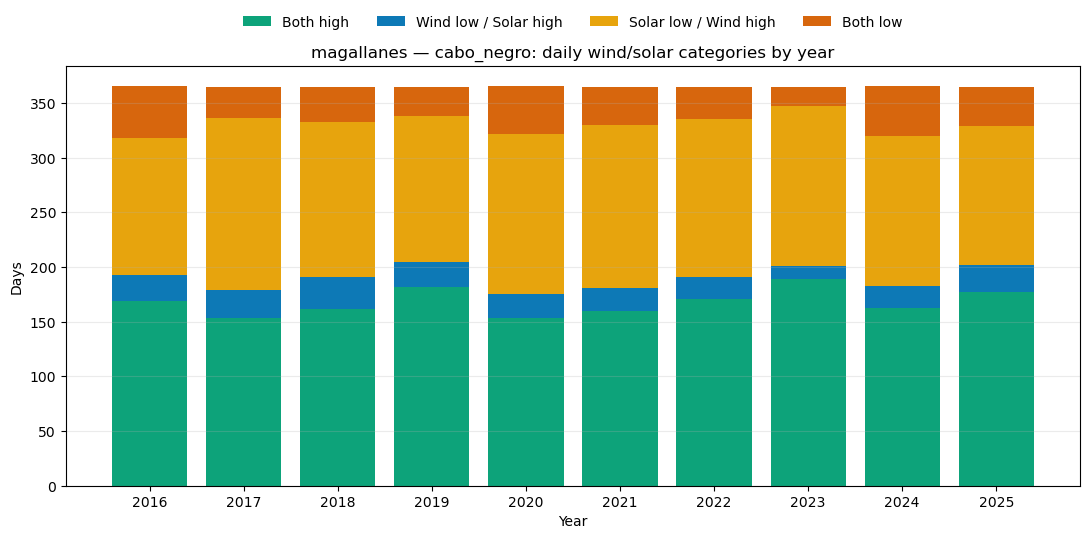

In [10]:

# Plot 2: stacked category counts by year at MAIN_SITE
counts_cols = [
    "both_high_days",
    "wind_low_solar_high_days",
    "solar_low_wind_high_days",
    "both_low_days",
]
counts_plot = summary_df.sort_values("year").set_index("year")[counts_cols]

label_map_counts = {
    "both_high_days": "Both high",
    "wind_low_solar_high_days": "Wind low / Solar high",
    "solar_low_wind_high_days": "Solar low / Wind high",
    "both_low_days": "Both low",
}
color_map_counts = {
    "both_high_days": category_colors["both_high"],
    "wind_low_solar_high_days": category_colors["wind_low_solar_high"],
    "solar_low_wind_high_days": category_colors["solar_low_wind_high"],
    "both_low_days": category_colors["both_low"],
}

fig, ax = plt.subplots(figsize=(11, 5.5))
bottom = np.zeros(len(counts_plot))
x = np.arange(len(counts_plot))

for col in counts_cols:
    ax.bar(
        x,
        counts_plot[col].values,
        bottom=bottom,
        color=color_map_counts[col],
        label=label_map_counts[col],
        alpha=0.95,
    )
    bottom += counts_plot[col].values

ax.set_xticks(x)
ax.set_xticklabels(counts_plot.index.astype(str))
ax.set_title(f"{CASE_NAME} — {MAIN_SITE}: daily wind/solar categories by year")
ax.set_xlabel("Year")
ax.set_ylabel("Days")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(ncol=4, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.15))
plt.tight_layout()
savefig(fig, f"{CASE_NAME}_{MAIN_SITE}_daily_category_counts_2016_2025.png")
plt.show()


Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2016_wind_vs_solar_daily_scatter.png


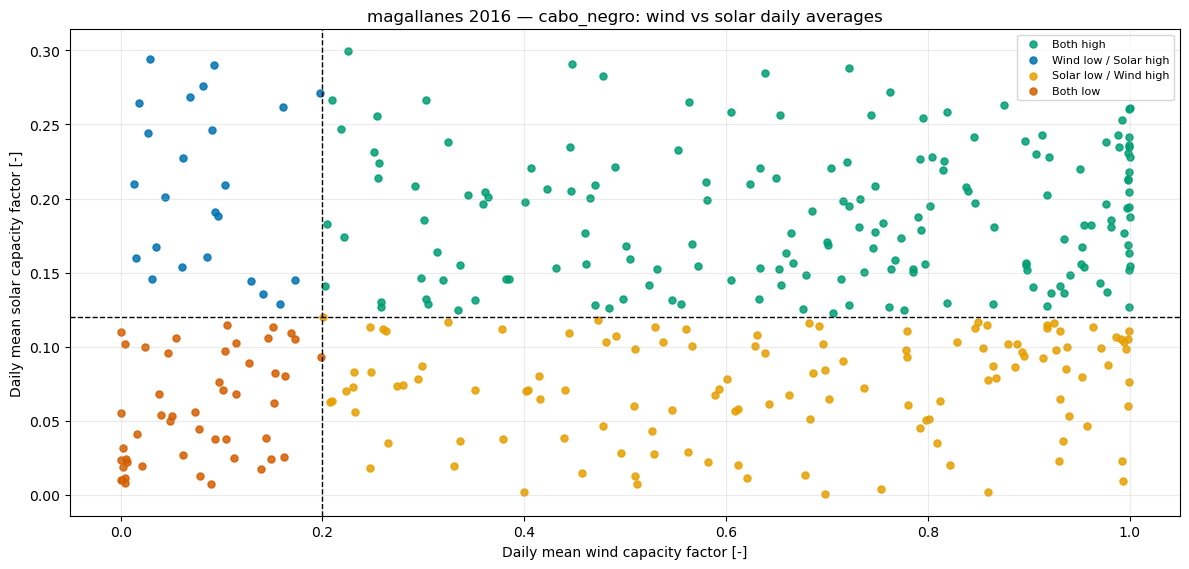

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2016_monthly_daily_category_strip.png


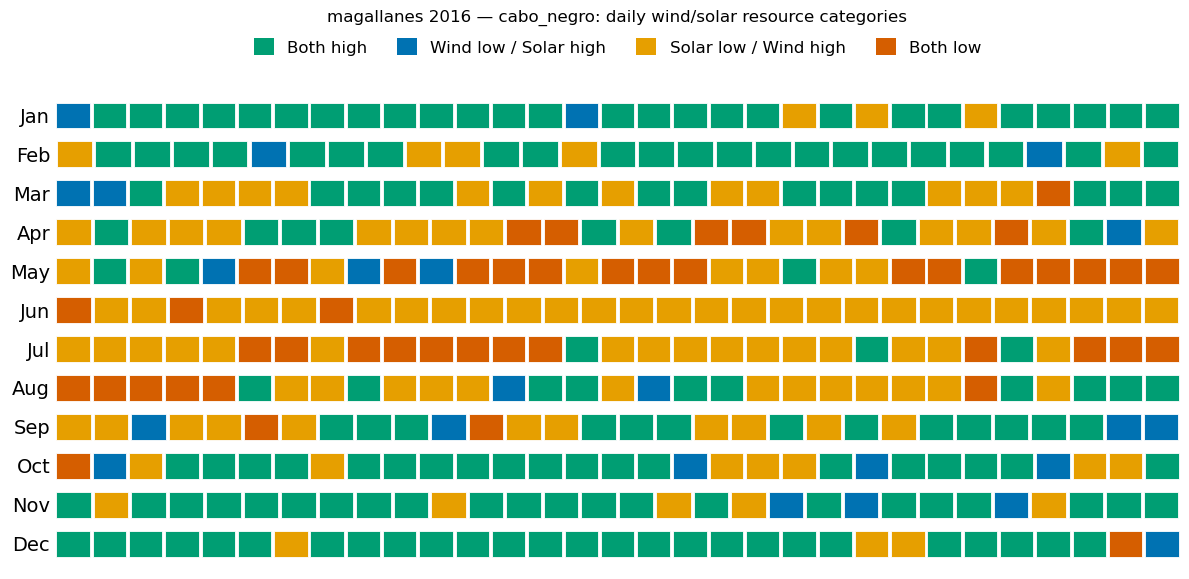

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2017_wind_vs_solar_daily_scatter.png


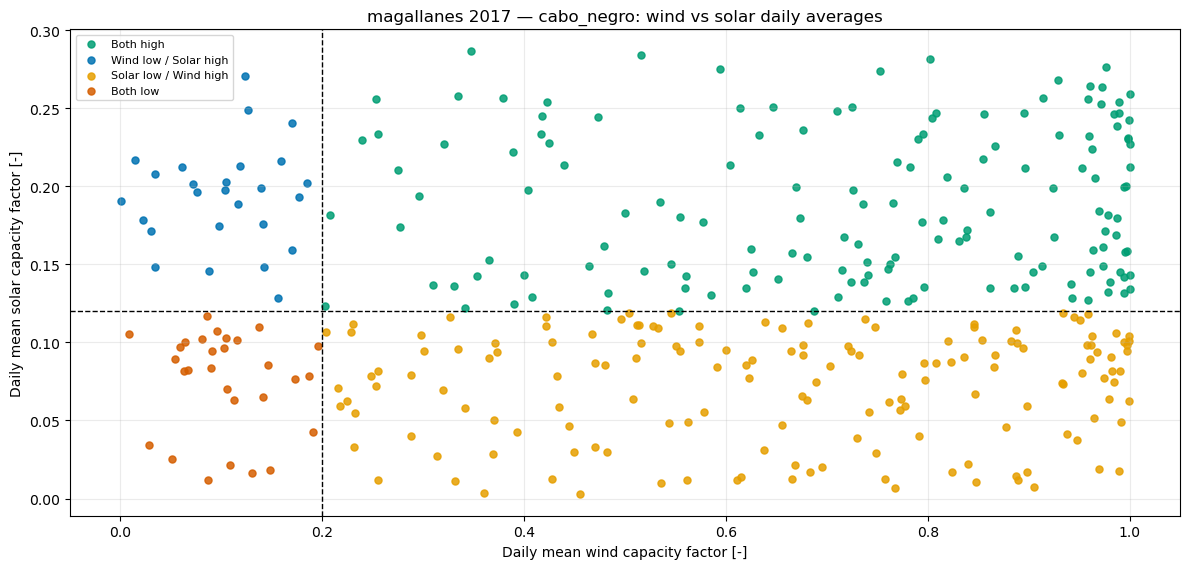

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2017_monthly_daily_category_strip.png


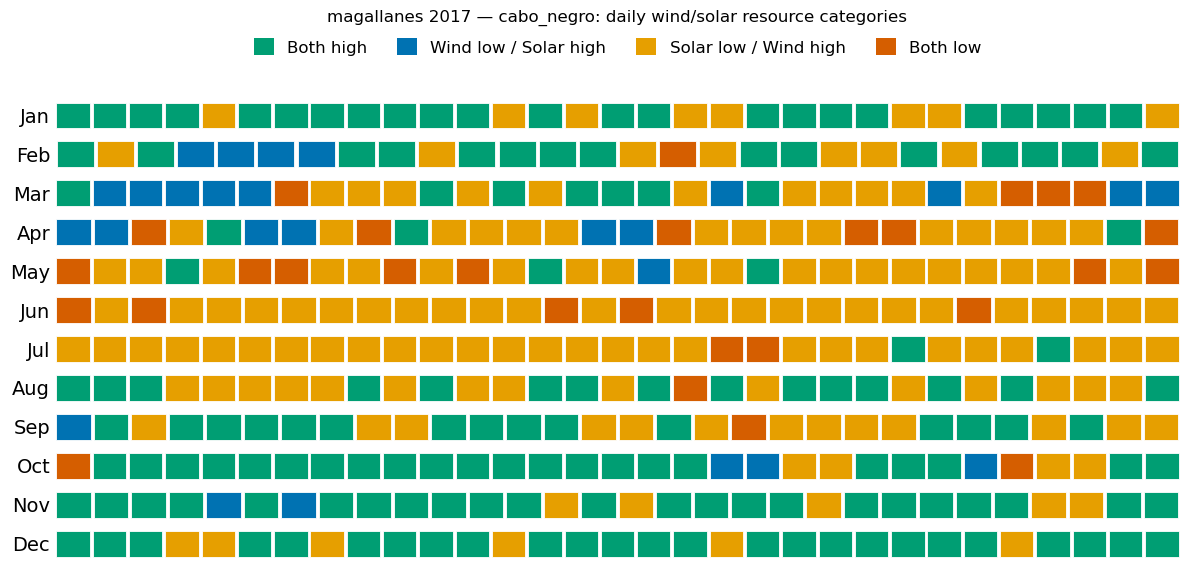

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2018_wind_vs_solar_daily_scatter.png


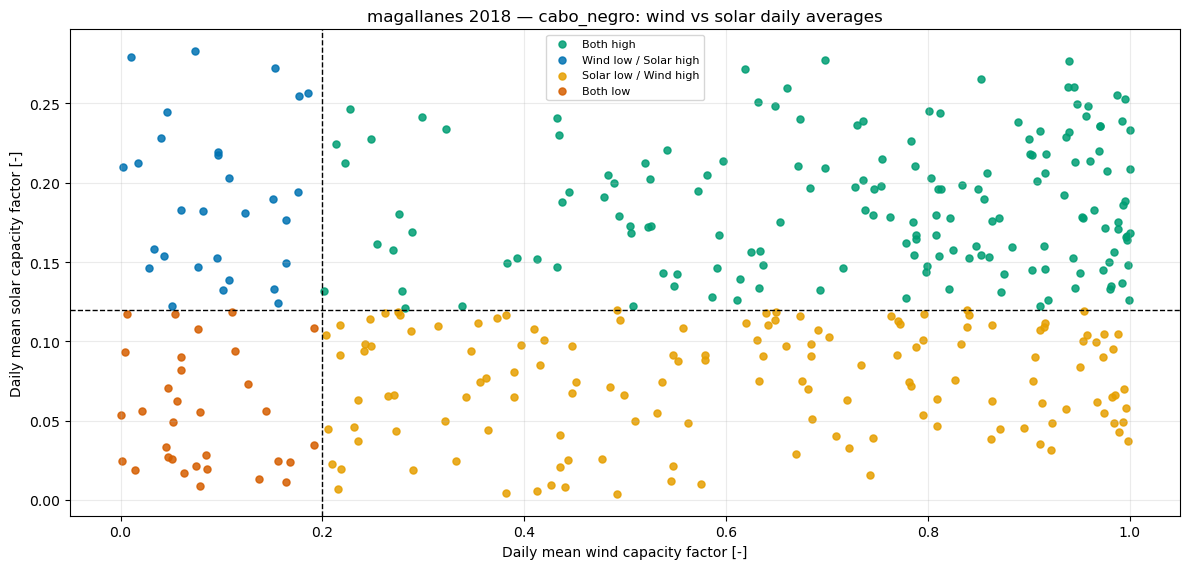

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2018_monthly_daily_category_strip.png


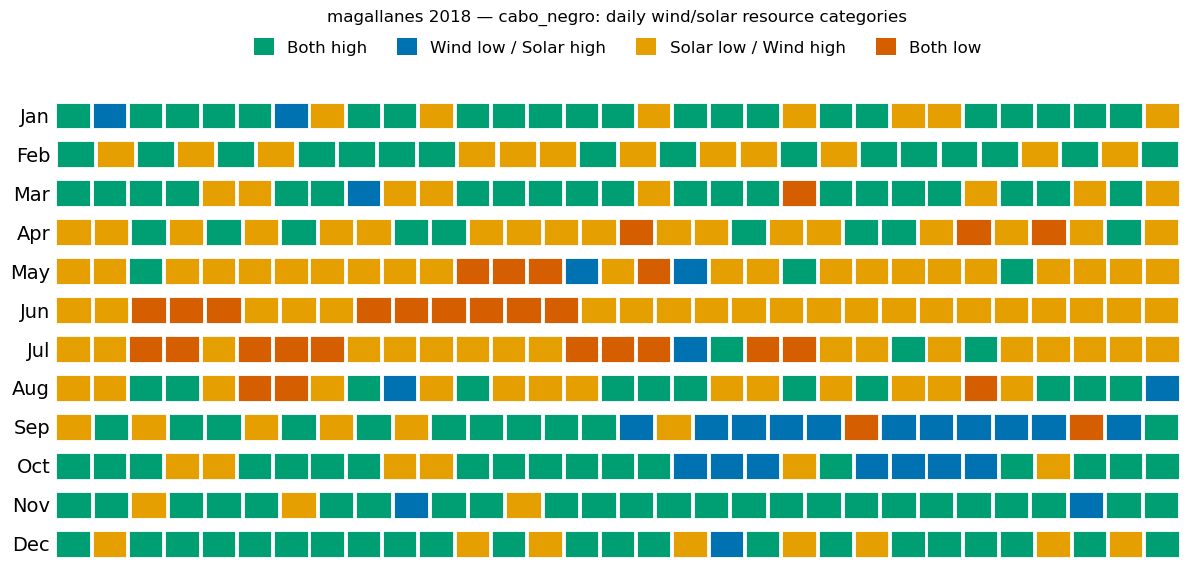

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2019_wind_vs_solar_daily_scatter.png


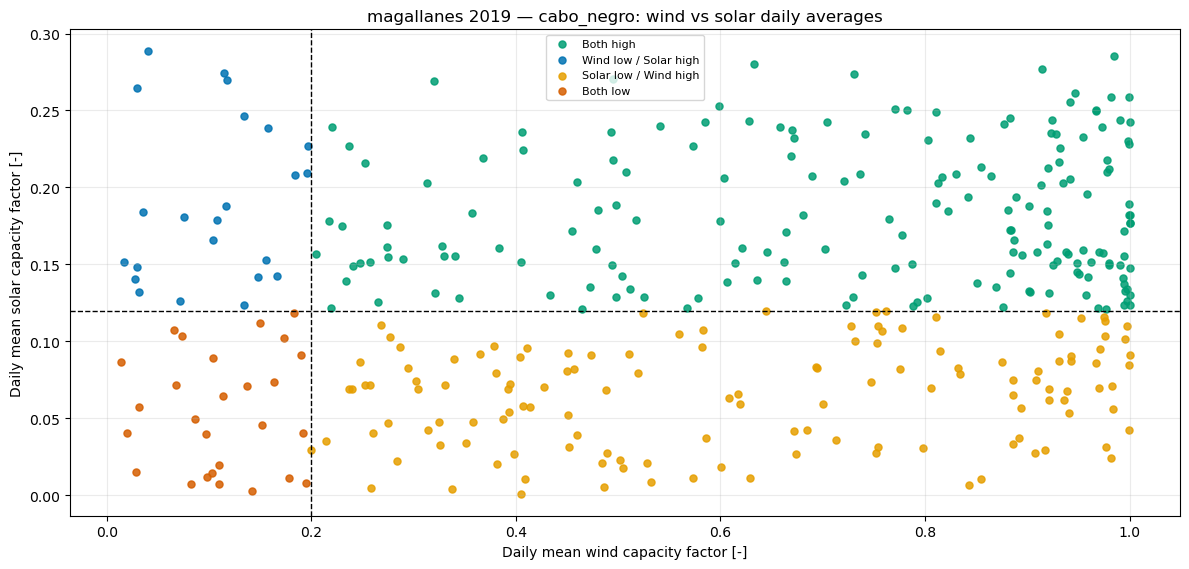

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2019_monthly_daily_category_strip.png


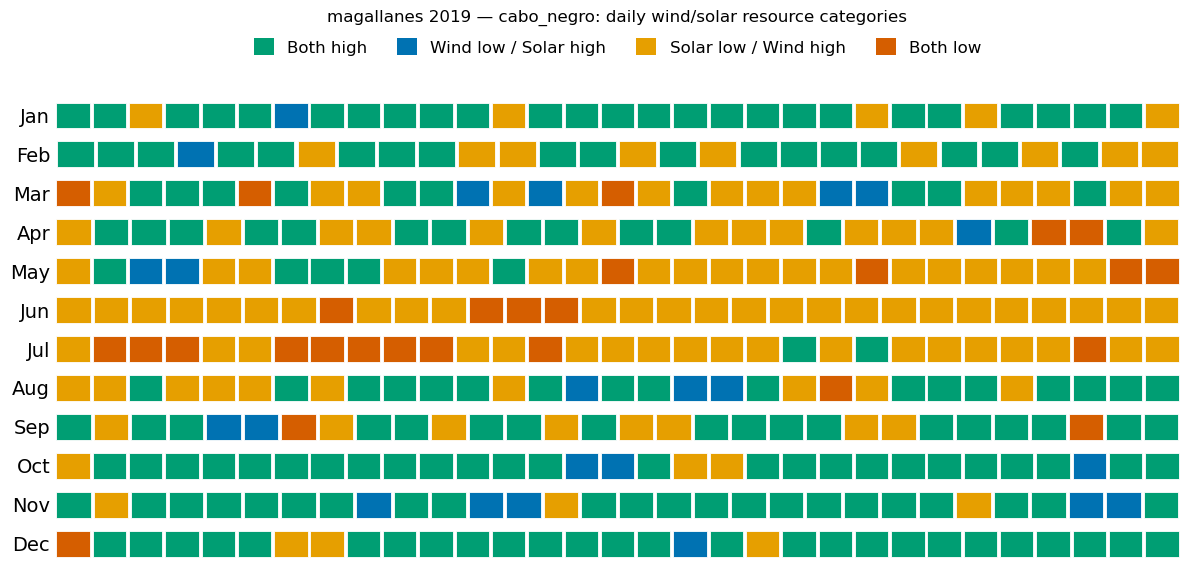

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2020_wind_vs_solar_daily_scatter.png


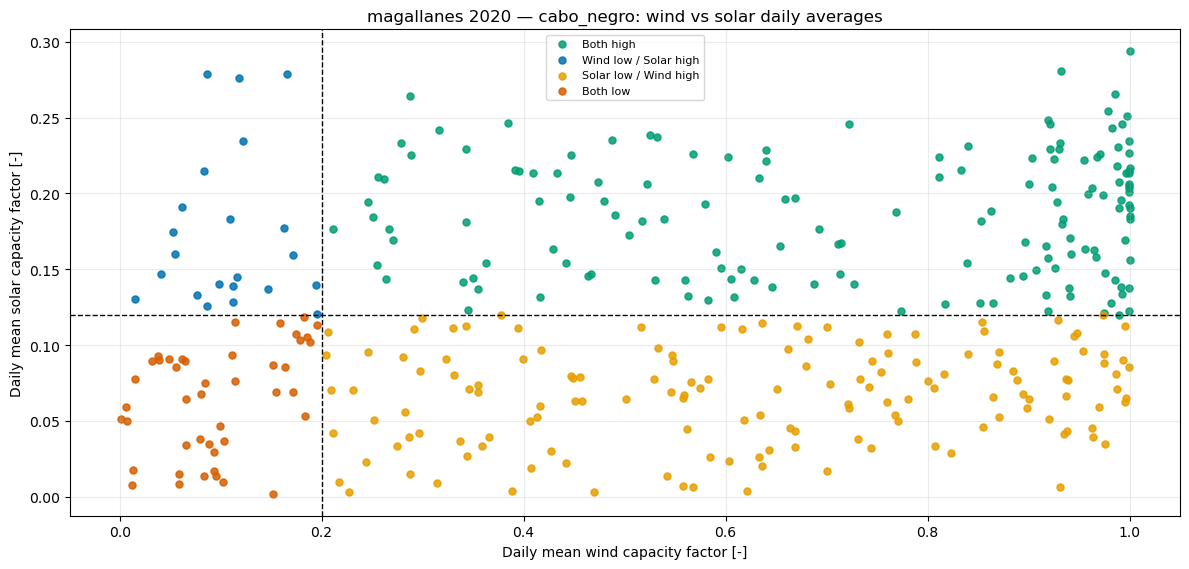

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2020_monthly_daily_category_strip.png


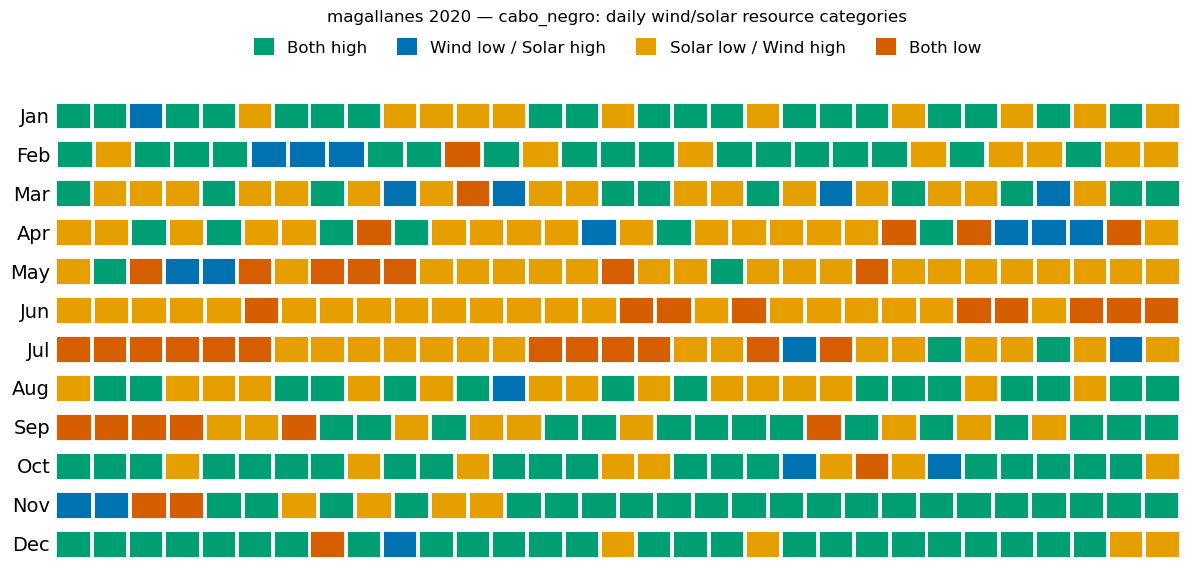

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2021_wind_vs_solar_daily_scatter.png


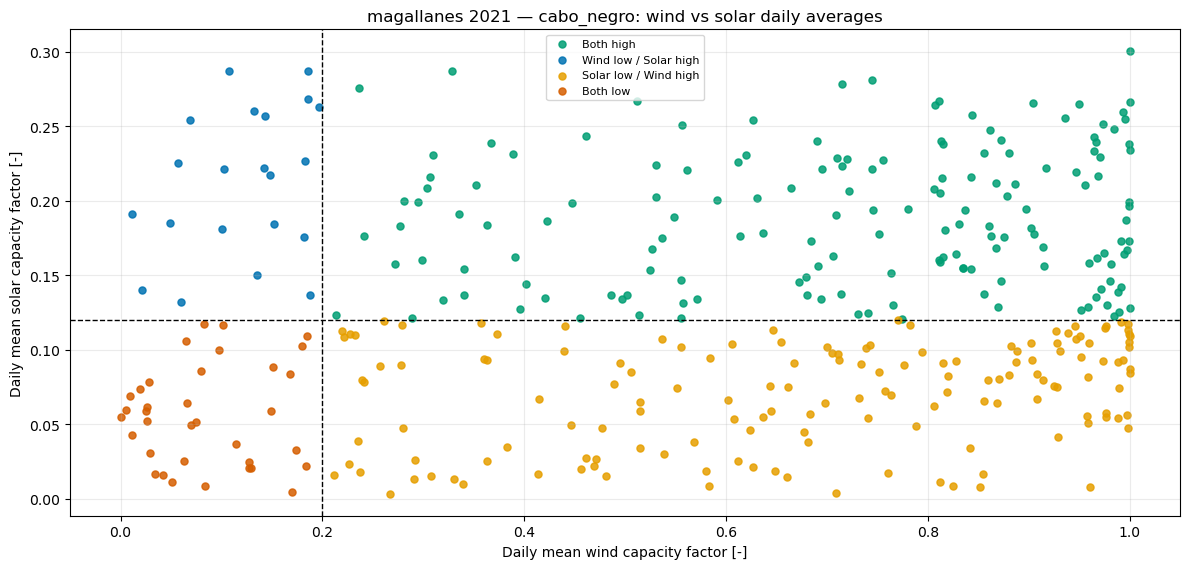

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2021_monthly_daily_category_strip.png


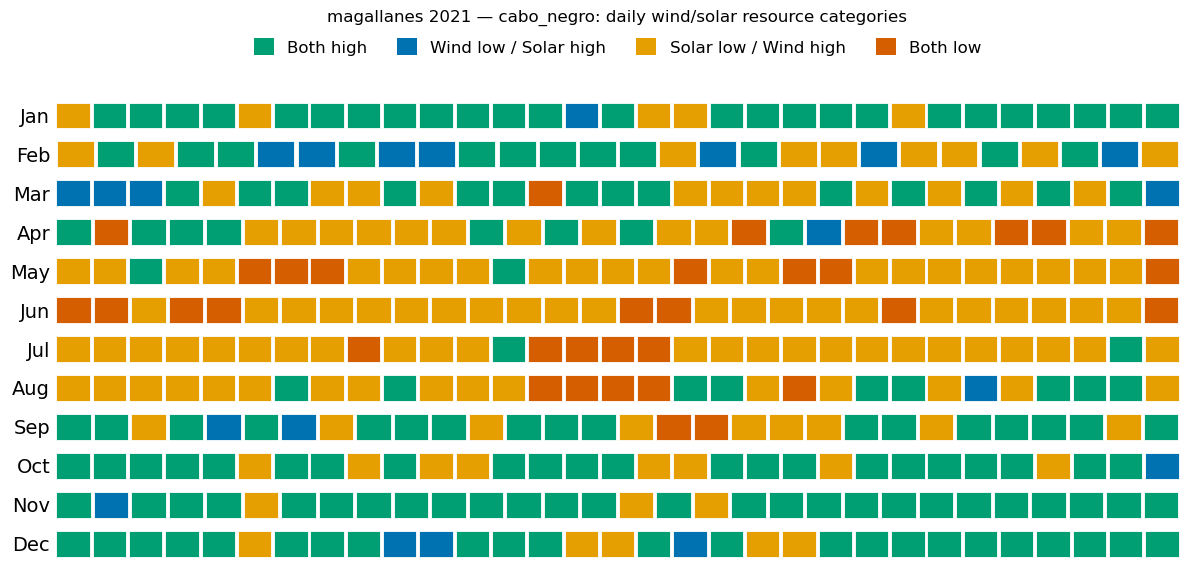

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2022_wind_vs_solar_daily_scatter.png


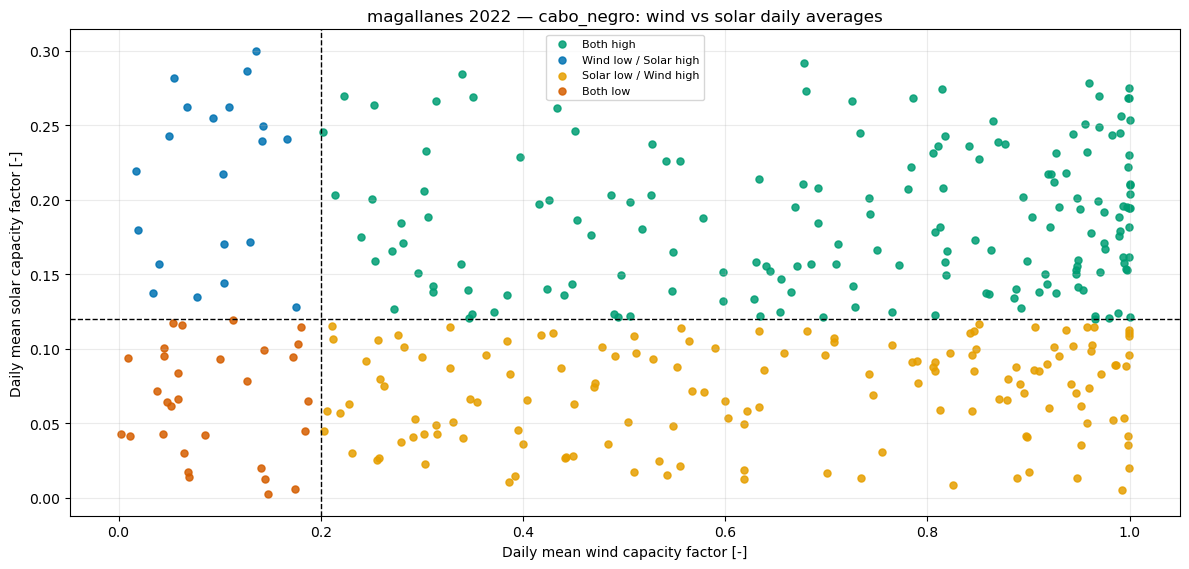

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2022_monthly_daily_category_strip.png


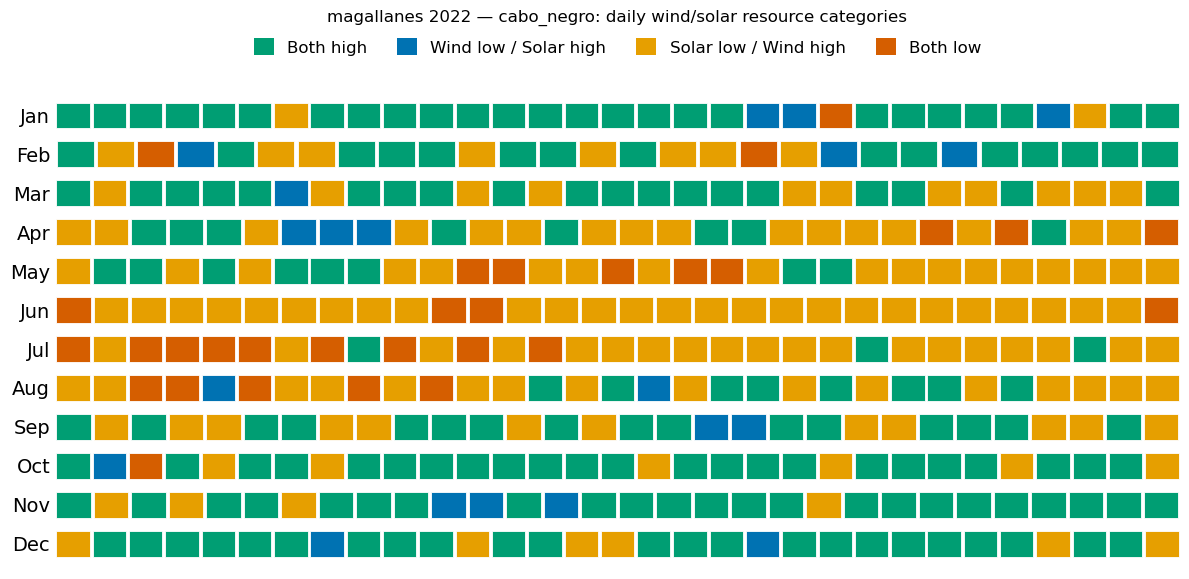

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2023_wind_vs_solar_daily_scatter.png


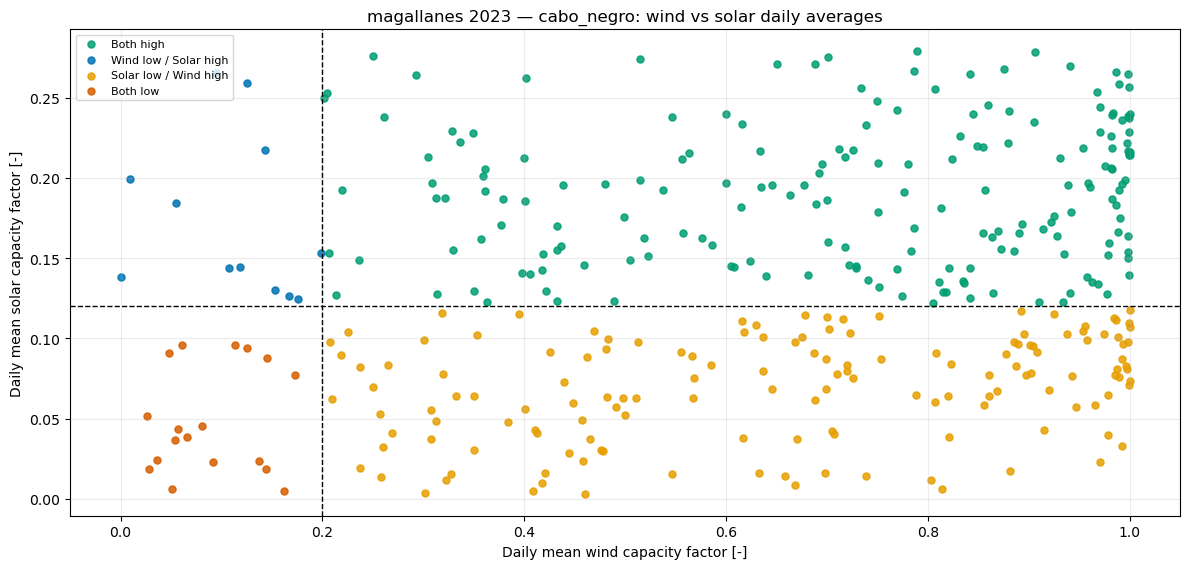

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2023_monthly_daily_category_strip.png


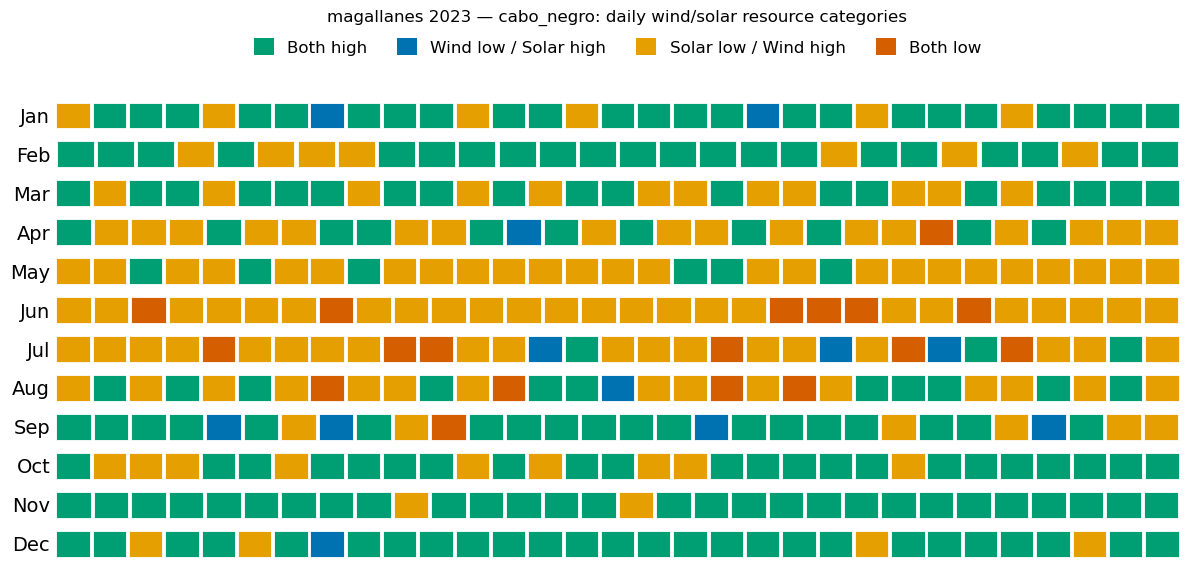

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2024_wind_vs_solar_daily_scatter.png


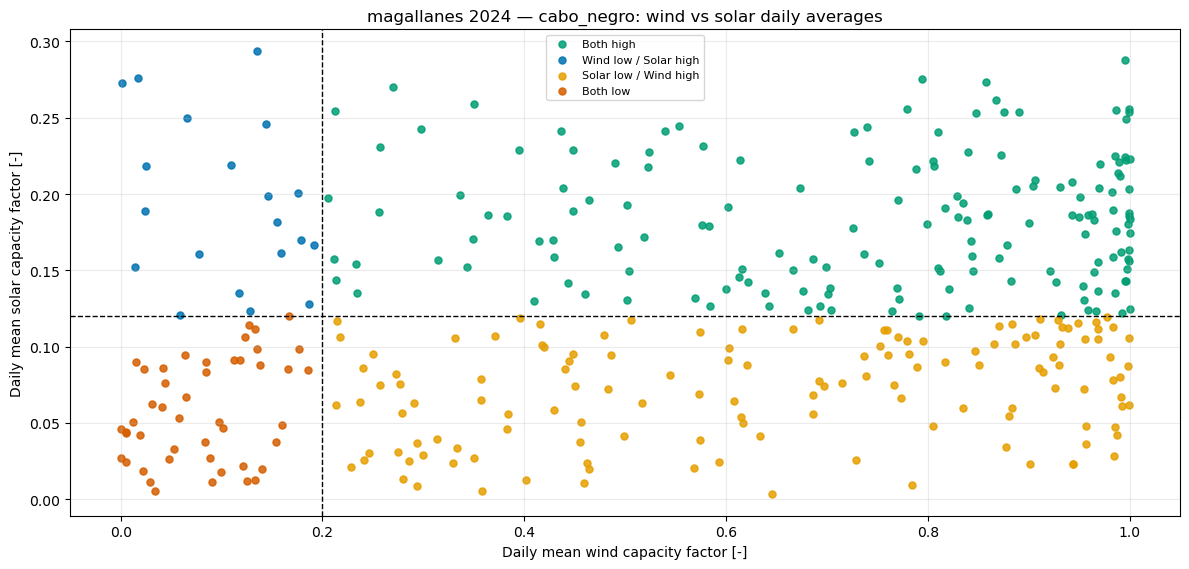

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2024_monthly_daily_category_strip.png


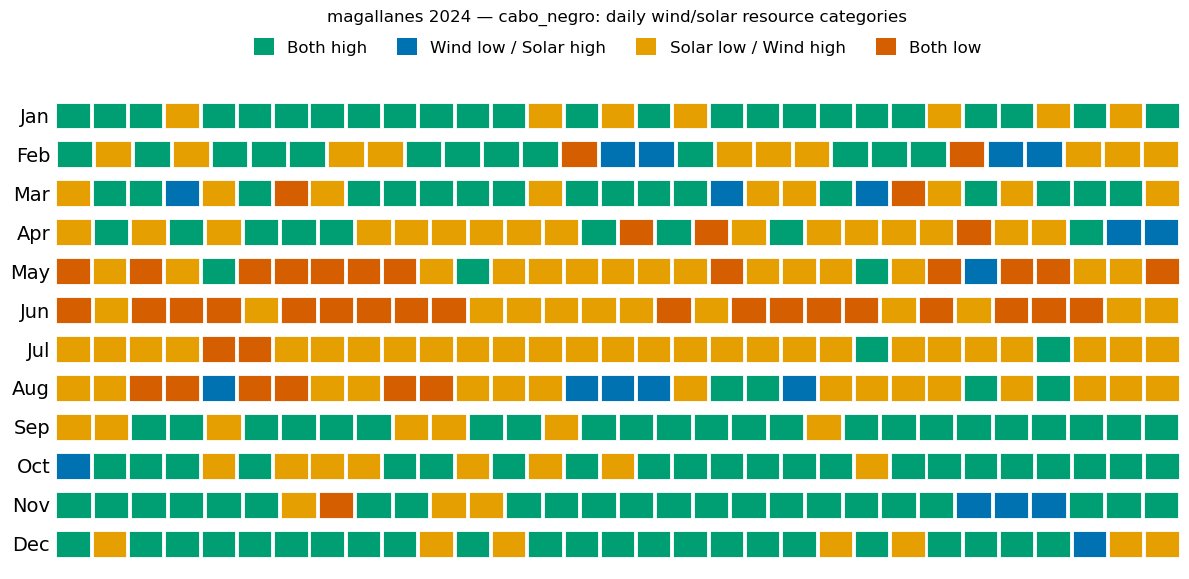

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2025_wind_vs_solar_daily_scatter.png


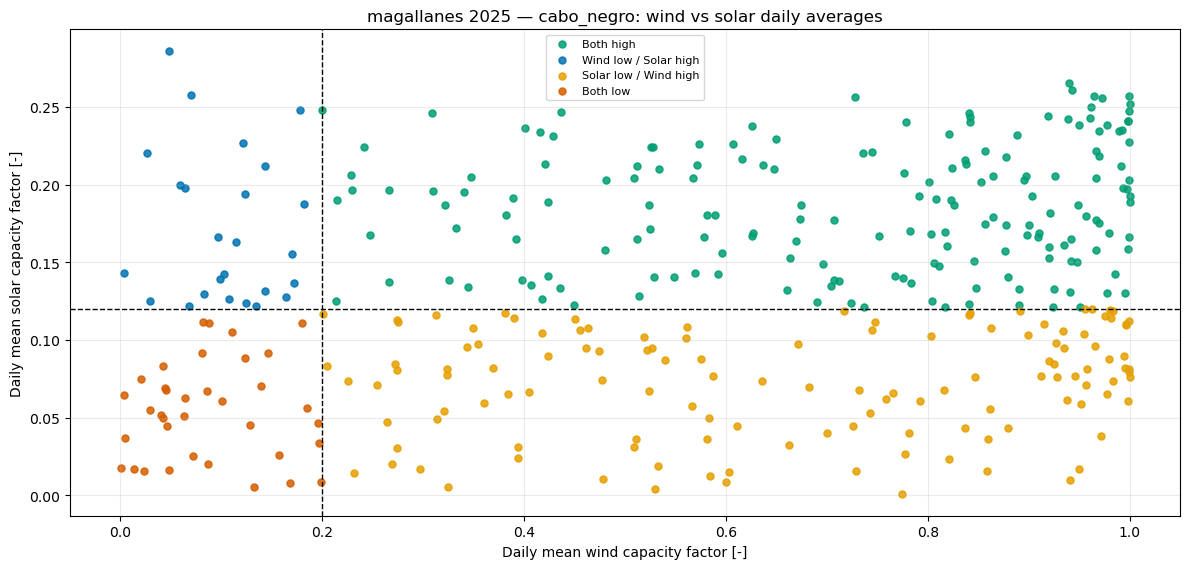

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2025_monthly_daily_category_strip.png


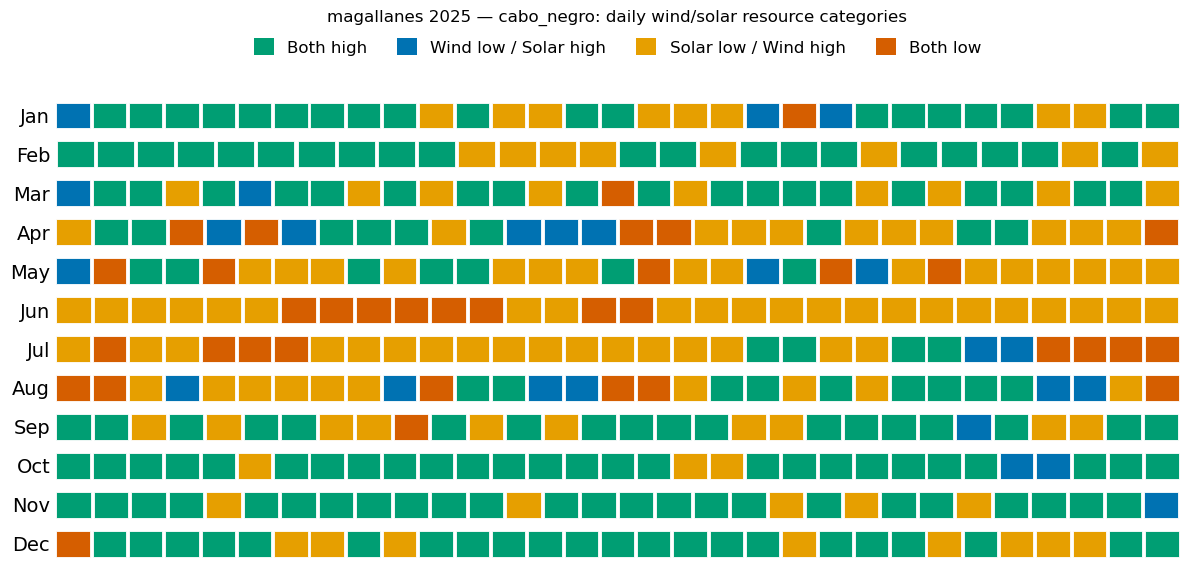

In [11]:

# Plot 3: wind vs solar scatter and monthly strips for each year at MAIN_SITE
if PLOT_EACH_YEAR:
    for year in sorted(main_daily_df["year"].unique()):
        year_df = main_daily_df[main_daily_df["year"] == year].copy()
        prefix = f"{CASE_NAME}_{MAIN_SITE}_{year}"
        plot_scatter(
            year_df,
            title=f"{CASE_NAME} {year} — {MAIN_SITE}: wind vs solar daily averages",
            filename_prefix=prefix,
        )
        plot_monthly_strip(
            year_df,
            year=year,
            title=f"{CASE_NAME} {year} — {MAIN_SITE}: daily wind/solar resource categories",
            filename_prefix=prefix,
        )


Saved: output_critical_weather_year\figures\magallanes_cabo_negro_category_strips_all_years_2016_2025.png


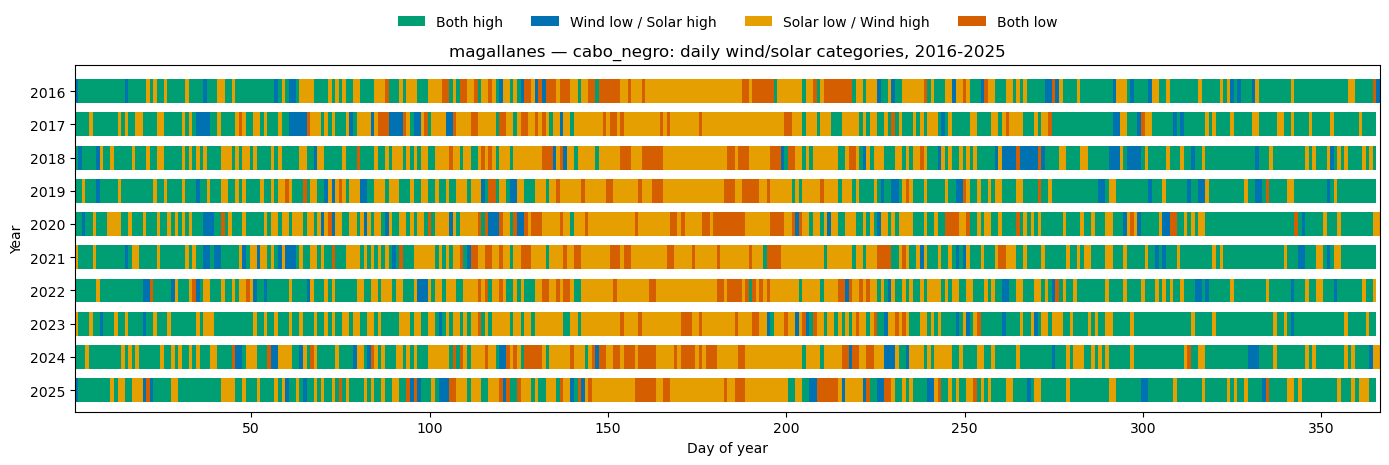

In [12]:

# Plot 4: compact 2016-2025 category strips at MAIN_SITE
fig, ax = plt.subplots(figsize=(14, 4.8))
years_sorted = sorted(main_daily_df["year"].unique())
y_positions = {year: len(years_sorted) - i for i, year in enumerate(years_sorted)}
row_height = 0.72

for year in years_sorted:
    y = y_positions[year]
    year_df = main_daily_df[main_daily_df["year"] == year].copy()
    for _, row in year_df.iterrows():
        d = int(row["dayofyear"])
        rect = Rectangle(
            (d - 0.5, y - row_height / 2),
            1.0,
            row_height,
            facecolor=category_colors[row["category"]],
            edgecolor="none",
        )
        ax.add_patch(rect)

ax.set_xlim(0.5, 366.5)
ax.set_ylim(0.35, len(years_sorted) + 0.8)
ax.set_yticks([y_positions[y] for y in years_sorted])
ax.set_yticklabels([str(y) for y in years_sorted])
ax.set_xlabel("Day of year")
ax.set_ylabel("Year")
ax.set_title(f"{CASE_NAME} — {MAIN_SITE}: daily wind/solar categories, 2016-2025")
ax.grid(False)

legend_handles = [Patch(facecolor=category_colors[c], edgecolor="none", label=category_labels[c]) for c in category_order]
ax.legend(handles=legend_handles, ncol=4, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.18))

plt.tight_layout()
savefig(fig, f"{CASE_NAME}_{MAIN_SITE}_category_strips_all_years_2016_2025.png")
plt.show()


Top 3 critical years at cabo_negro: [2020, 2016, 2025]
Saved: output_critical_weather_year\figures\magallanes_cabo_negro_top3_critical_years_wind_cf.png


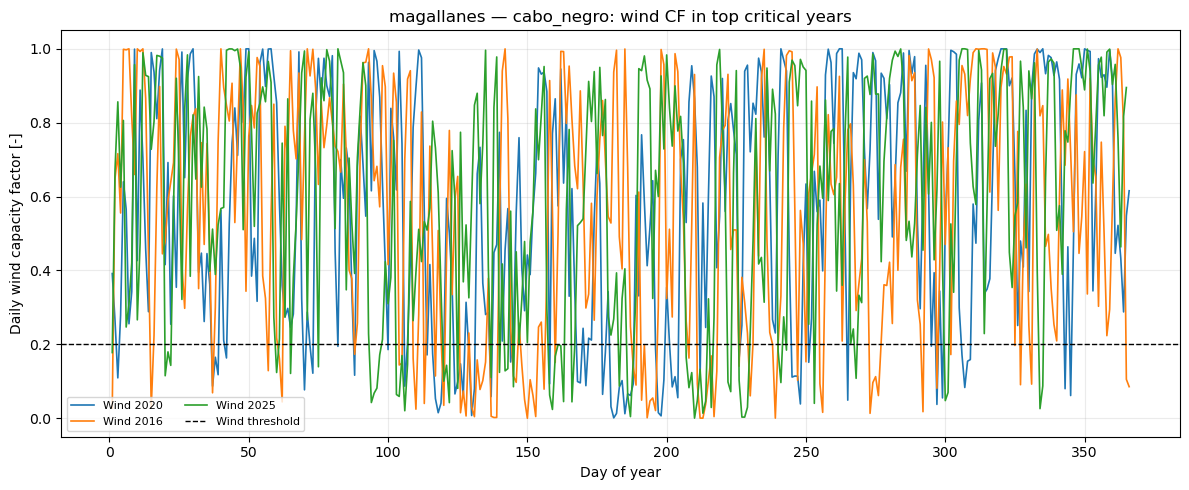

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_top3_critical_years_solar_cf.png


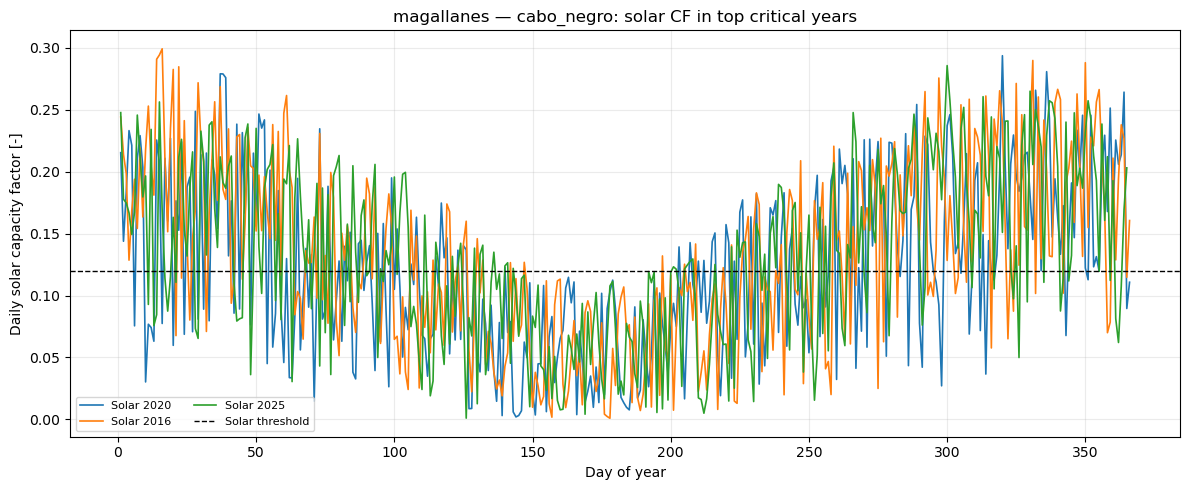

In [13]:

# Optional focus plots for top-ranked years at MAIN_SITE
if PLOT_TOP_N_YEARS and PLOT_TOP_N_YEARS > 0:
    top_years = summary_df.head(PLOT_TOP_N_YEARS)["year"].astype(int).tolist()
    print(f"Top {PLOT_TOP_N_YEARS} critical years at {MAIN_SITE}: {top_years}")

    fig, ax = plt.subplots(figsize=(12, 5))
    for year in top_years:
        year_df = main_daily_df[main_daily_df["year"] == year].copy()
        ax.plot(year_df["dayofyear"], year_df["wind_cf"], label=f"Wind {year}", linewidth=1.2)
    ax.axhline(LOW_WIND_THRESHOLD, color="black", linestyle="--", linewidth=1.0, label="Wind threshold")
    ax.set_title(f"{CASE_NAME} — {MAIN_SITE}: wind CF in top critical years")
    ax.set_xlabel("Day of year")
    ax.set_ylabel("Daily wind capacity factor [-]")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    savefig(fig, f"{CASE_NAME}_{MAIN_SITE}_top{PLOT_TOP_N_YEARS}_critical_years_wind_cf.png")
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 5))
    for year in top_years:
        year_df = main_daily_df[main_daily_df["year"] == year].copy()
        ax.plot(year_df["dayofyear"], year_df["solar_cf"], label=f"Solar {year}", linewidth=1.2)
    ax.axhline(LOW_SOLAR_THRESHOLD, color="black", linestyle="--", linewidth=1.0, label="Solar threshold")
    ax.set_title(f"{CASE_NAME} — {MAIN_SITE}: solar CF in top critical years")
    ax.set_xlabel("Day of year")
    ax.set_ylabel("Daily solar capacity factor [-]")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    savefig(fig, f"{CASE_NAME}_{MAIN_SITE}_top{PLOT_TOP_N_YEARS}_critical_years_solar_cf.png")
    plt.show()



## Spatial comparison during the selected critical year

The next section compares the strategic sites using the **same selected critical year** from the main-site analysis. This is not used to choose the critical year; it is a complementary test of whether low-resource periods are spatially synchronized or partially diversified across the region.


In [14]:

# Spatial comparison for the selected critical year
if PLOT_SPATIAL_COMPARISON:
    spatial_daily_df = daily_sites_df[daily_sites_df["year"] == critical_year].copy()

    spatial_summary_rows = []
    for site, group in spatial_daily_df.groupby("site"):
        spatial_summary_rows.append(compute_metrics(group, critical_year, site))

    spatial_summary_df = pd.DataFrame(spatial_summary_rows).sort_values(
        ["max_consecutive_both_low_days", "both_low_days", "max_consecutive_wind_low_days"],
        ascending=[False, False, False],
    ).reset_index(drop=True)
    spatial_summary_df.insert(0, "rank", np.arange(1, len(spatial_summary_df) + 1))

    spatial_summary_csv = TABLES_DIR / f"{CASE_NAME}_spatial_comparison_{critical_year}_summary.csv"
    spatial_daily_csv = TABLES_DIR / f"{CASE_NAME}_spatial_comparison_{critical_year}_daily_categories.csv"
    spatial_summary_df.to_csv(spatial_summary_csv, index=False)
    spatial_daily_df.to_csv(spatial_daily_csv)

    print(f"Critical year selected from {MAIN_SITE}: {critical_year}")
    print(f"Saved: {spatial_summary_csv}")
    print(f"Saved: {spatial_daily_csv}")
    display(spatial_summary_df)


Critical year selected from cabo_negro: 2020
Saved: output_critical_weather_year\tables\magallanes_spatial_comparison_2020_summary.csv
Saved: output_critical_weather_year\tables\magallanes_spatial_comparison_2020_daily_categories.csv


,rank,site,year,days,wind_cf_mean,solar_cf_mean,both_low_days,wind_low_solar_high_days,solar_low_wind_high_days,both_high_days,...,max_consecutive_wind_low_days,max_wind_low_start,max_wind_low_end,max_consecutive_solar_low_days,max_solar_low_start,max_solar_low_end,worst_month_both_low_run,worst_month_both_low_days,worst_month_by_run,worst_month_by_days
0,1,rio_verde,2020,366,0.503970,0.125039,70,29,125,142,...,14,2020-06-25,2020-07-08,57,2020-05-29,2020-07-24,8,15,Jul,Jul
1,2,villa_tehuelches,2020,366,0.542969,0.126704,62,28,130,146,...,14,2020-06-25,2020-07-08,43,2020-05-29,2020-07-10,8,13,Jul,Jun
2,3,punta_arenas,2020,366,0.519461,0.122802,60,24,129,153,...,9,2020-06-28,2020-07-06,62,2020-05-20,2020-07-20,7,15,Jul,Jul
3,4,cabo_negro,2020,366,0.576391,0.122746,44,22,147,153,...,9,2020-06-28,2020-07-06,62,2020-05-20,2020-07-20,6,12,Jul,Jul
4,5,san_gregorio,2020,366,0.610845,0.131137,35,24,145,162,...,9,2020-06-28,2020-07-06,44,2020-05-29,2020-07-11,6,10,Jul,Jul
5,6,punta_delgada,2020,366,0.617575,0.132848,33,25,137,171,...,9,2020-06-28,2020-07-06,53,2020-05-29,2020-07-20,6,10,Jul,Jul


Saved: output_critical_weather_year\figures\magallanes_spatial_ranking_both_low_streak_2020.png


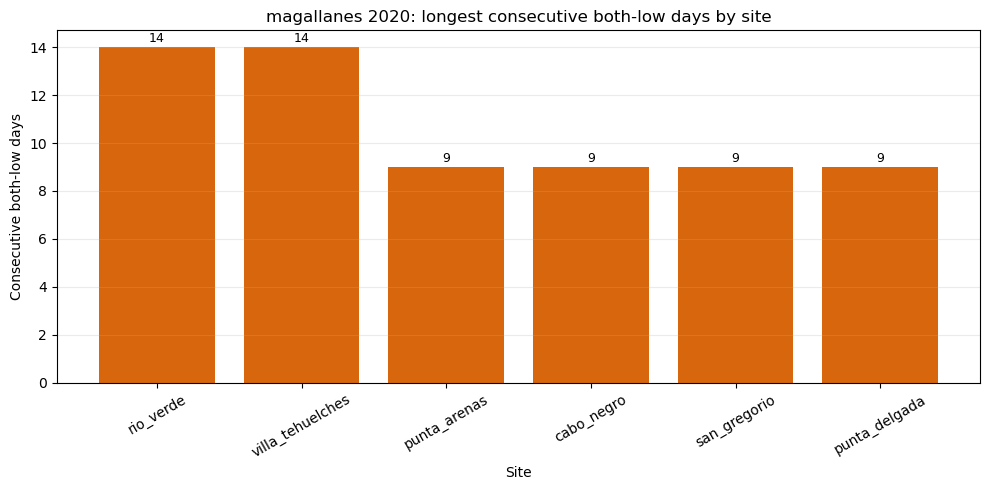

In [15]:

# Spatial plot 1: criticality ranking by site during the selected critical year
if PLOT_SPATIAL_COMPARISON:
    plot_df = spatial_summary_df.copy()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(
        plot_df["site"],
        plot_df["max_consecutive_both_low_days"],
        color=category_colors["both_low"],
        alpha=0.95,
    )
    ax.set_title(f"{CASE_NAME} {critical_year}: longest consecutive both-low days by site")
    ax.set_xlabel("Site")
    ax.set_ylabel("Consecutive both-low days")
    ax.grid(True, axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=30)

    for x, y in zip(plot_df["site"], plot_df["max_consecutive_both_low_days"]):
        ax.text(x, y + 0.1, str(int(y)), ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    savefig(fig, f"{CASE_NAME}_spatial_ranking_both_low_streak_{critical_year}.png")
    plt.show()


Saved: output_critical_weather_year\figures\magallanes_spatial_category_strips_2020.png


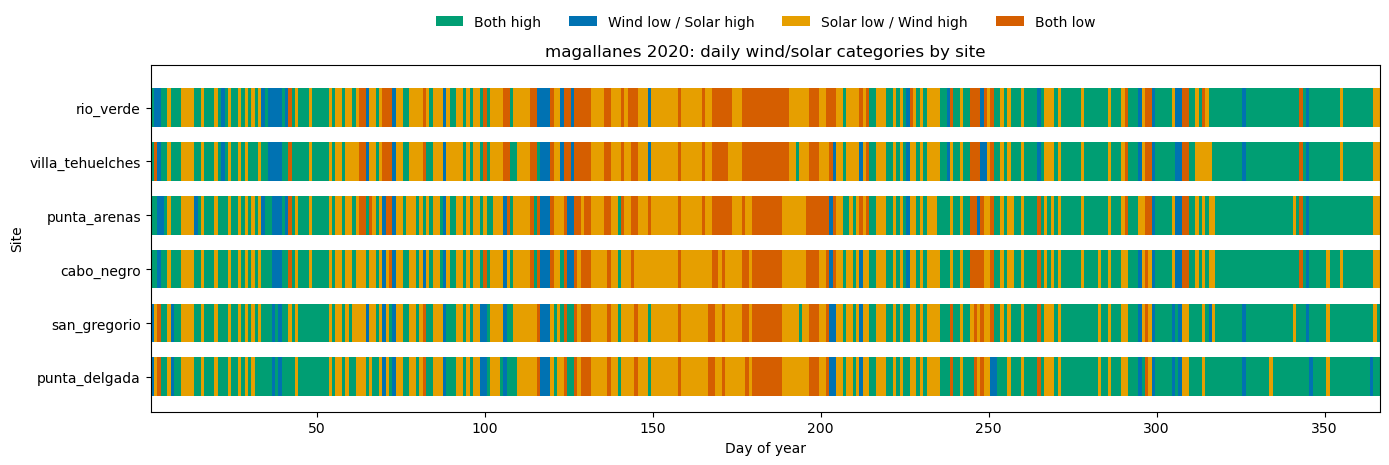

In [16]:

# Spatial plot 2: compact category strips by site during the selected critical year
if PLOT_SPATIAL_COMPARISON:
    fig, ax = plt.subplots(figsize=(14, 4.8))
    sites_sorted = spatial_summary_df["site"].tolist()
    y_positions = {site: len(sites_sorted) - i for i, site in enumerate(sites_sorted)}
    row_height = 0.72

    for site in sites_sorted:
        y = y_positions[site]
        site_df = spatial_daily_df[spatial_daily_df["site"] == site].copy()
        for _, row in site_df.iterrows():
            d = int(row["dayofyear"])
            rect = Rectangle(
                (d - 0.5, y - row_height / 2),
                1.0,
                row_height,
                facecolor=category_colors[row["category"]],
                edgecolor="none",
            )
            ax.add_patch(rect)

    ax.set_xlim(0.5, 366.5)
    ax.set_ylim(0.35, len(sites_sorted) + 0.8)
    ax.set_yticks([y_positions[s] for s in sites_sorted])
    ax.set_yticklabels(sites_sorted)
    ax.set_xlabel("Day of year")
    ax.set_ylabel("Site")
    ax.set_title(f"{CASE_NAME} {critical_year}: daily wind/solar categories by site")
    ax.grid(False)

    legend_handles = [Patch(facecolor=category_colors[c], edgecolor="none", label=category_labels[c]) for c in category_order]
    ax.legend(handles=legend_handles, ncol=4, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.18))

    plt.tight_layout()
    savefig(fig, f"{CASE_NAME}_spatial_category_strips_{critical_year}.png")
    plt.show()


Saved: output_critical_weather_year\figures\magallanes_rio_verde_2020_wind_vs_solar_daily_scatter.png


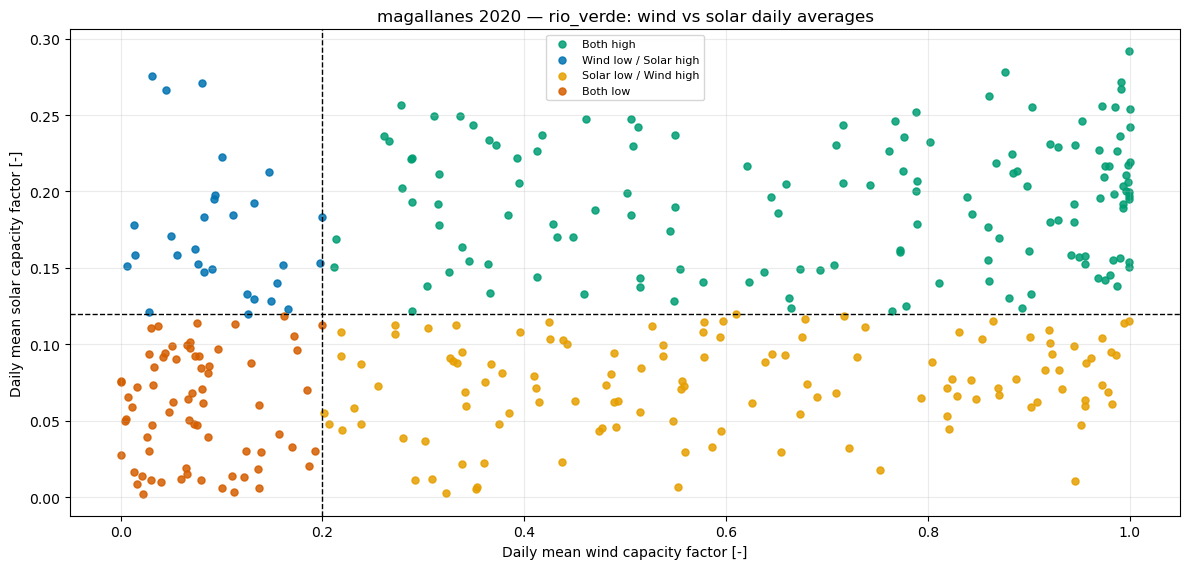

Saved: output_critical_weather_year\figures\magallanes_villa_tehuelches_2020_wind_vs_solar_daily_scatter.png


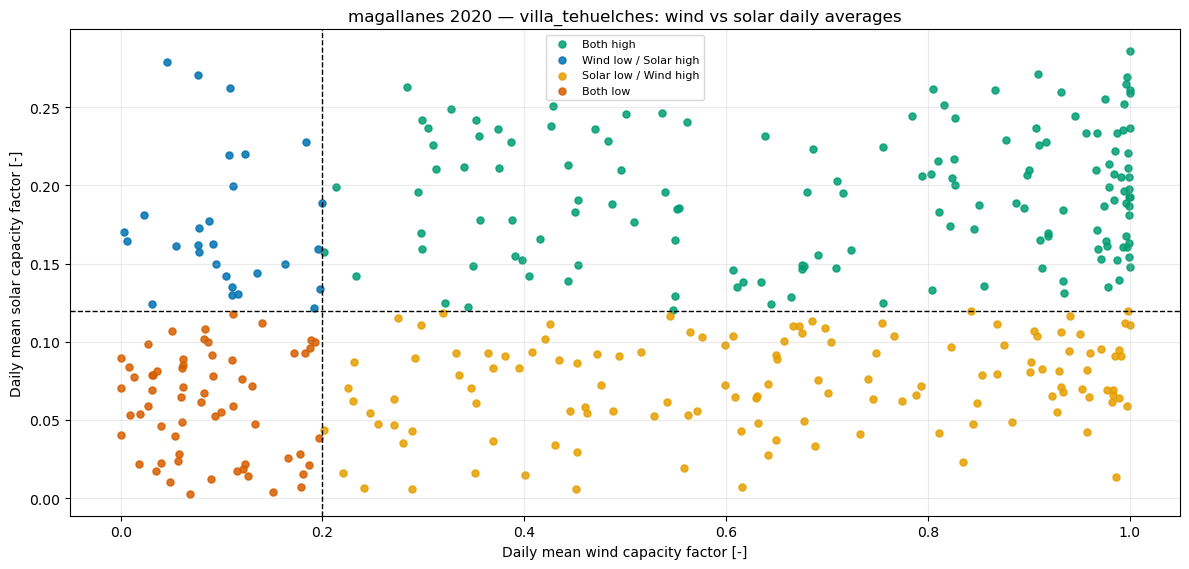

Saved: output_critical_weather_year\figures\magallanes_punta_arenas_2020_wind_vs_solar_daily_scatter.png


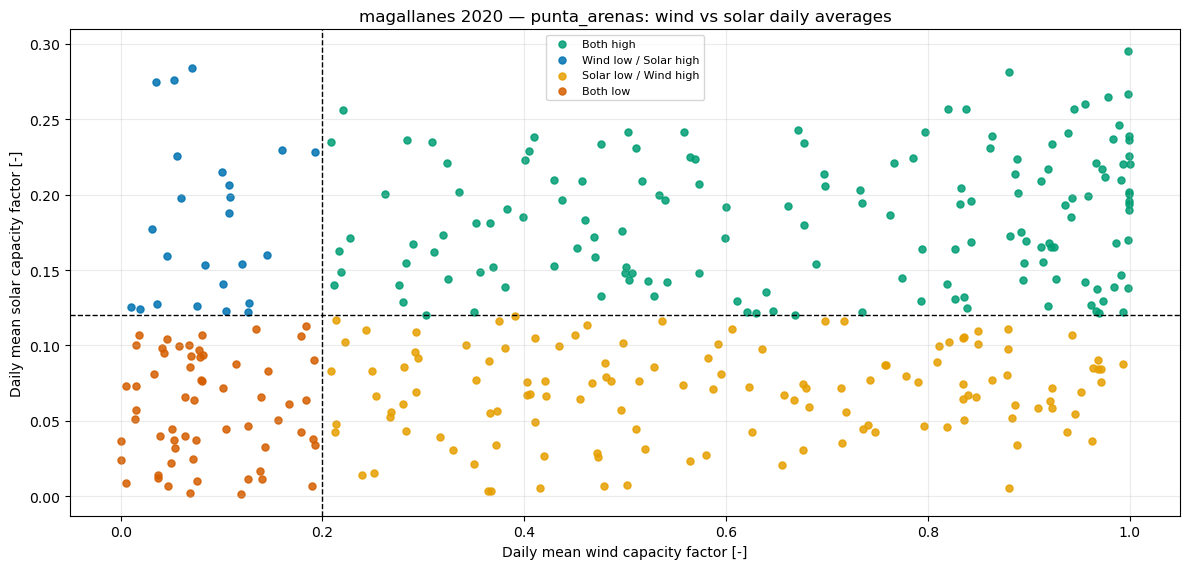

Saved: output_critical_weather_year\figures\magallanes_cabo_negro_2020_wind_vs_solar_daily_scatter.png


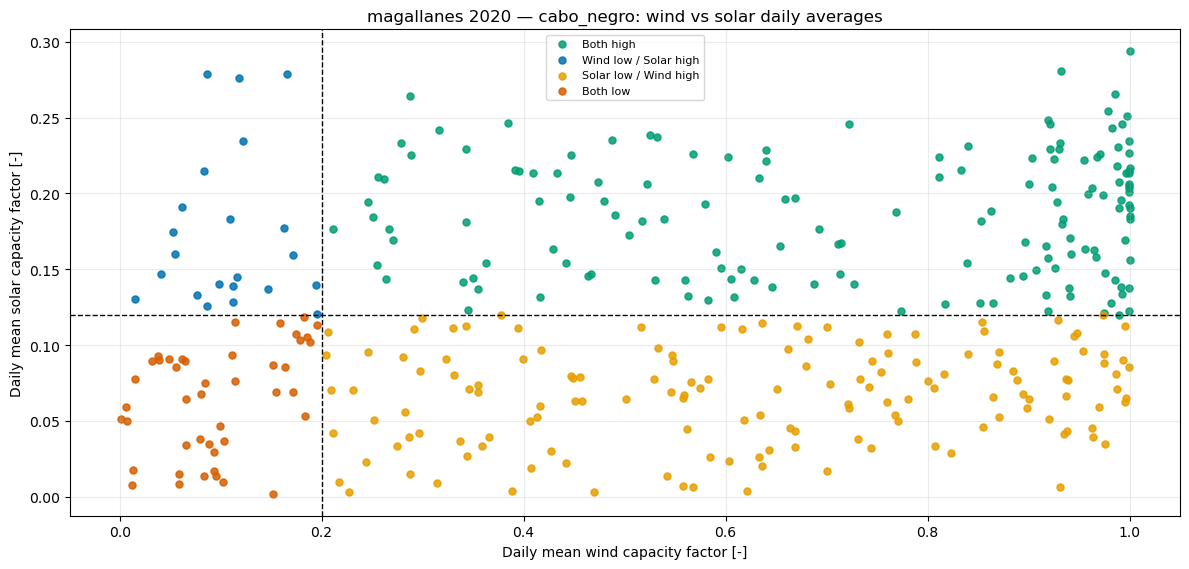

Saved: output_critical_weather_year\figures\magallanes_san_gregorio_2020_wind_vs_solar_daily_scatter.png


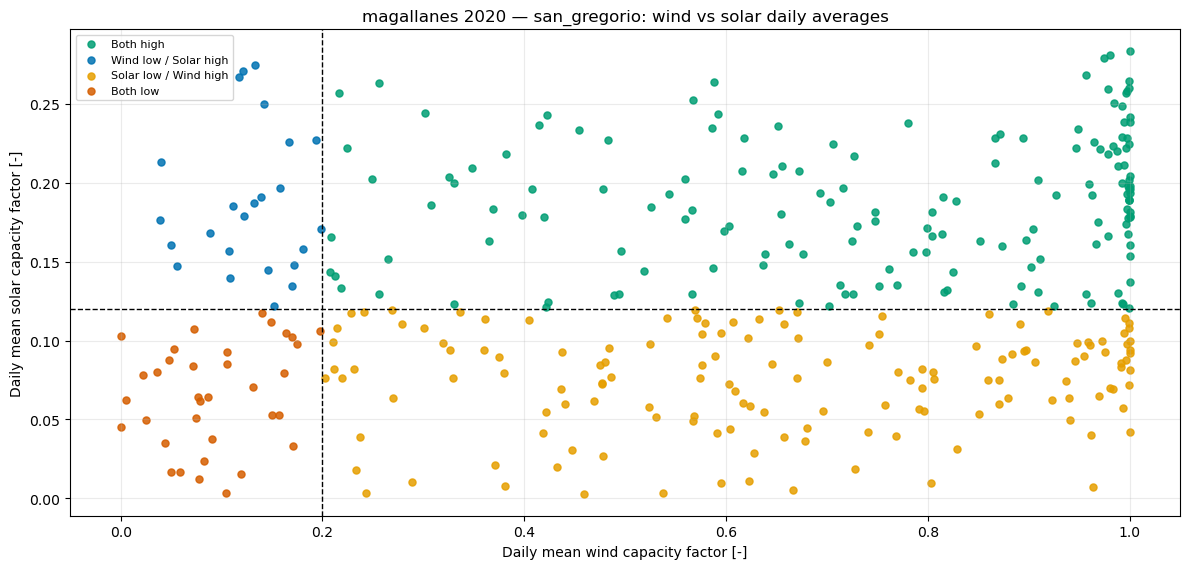

Saved: output_critical_weather_year\figures\magallanes_punta_delgada_2020_wind_vs_solar_daily_scatter.png


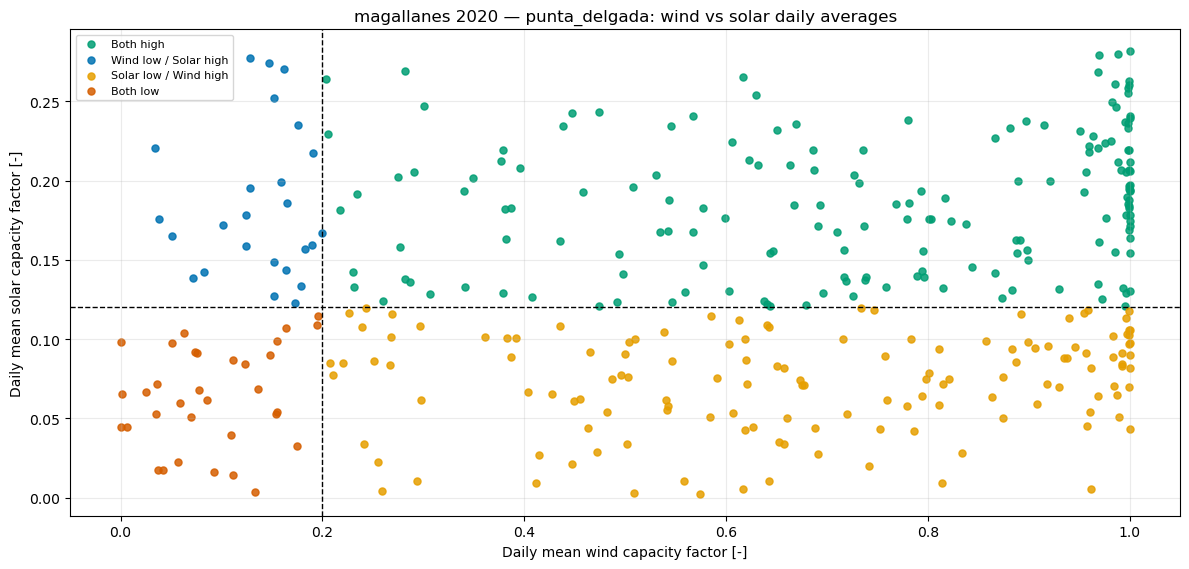

In [17]:

# Spatial plot 3: wind vs solar scatter for each site during the selected critical year
if PLOT_SPATIAL_COMPARISON:
    for site in spatial_summary_df["site"].tolist():
        site_df = spatial_daily_df[spatial_daily_df["site"] == site].copy()
        prefix = f"{CASE_NAME}_{site}_{critical_year}"
        plot_scatter(
            site_df,
            title=f"{CASE_NAME} {critical_year} — {site}: wind vs solar daily averages",
            filename_prefix=prefix,
        )


In [18]:

# Optional: threshold sensitivity at MAIN_SITE
# This does not recompute CF. It only reclassifies the existing daily wind/solar table.

sensitivity_thresholds = [
    (0.15, 0.10),
    (0.20, 0.12),
    (0.25, 0.15),
]

sensitivity_rows = []
base_daily_cf = main_daily_df[["year", "site", "wind_cf", "solar_cf"]].copy()

for wind_thr, solar_thr in sensitivity_thresholds:
    for year, group in base_daily_cf.groupby("year"):
        classified = classify_wind_solar_days(group[["wind_cf", "solar_cf"]], wind_thr, solar_thr)
        metrics = compute_metrics(classified, int(year), MAIN_SITE)
        sensitivity_rows.append({
            "wind_threshold": wind_thr,
            "solar_threshold": solar_thr,
            "site": MAIN_SITE,
            "year": int(year),
            "both_low_days": metrics["both_low_days"],
            "max_consecutive_both_low_days": metrics["max_consecutive_both_low_days"],
            "max_both_low_start": metrics["max_both_low_start"],
            "max_both_low_end": metrics["max_both_low_end"],
        })

sensitivity_df = pd.DataFrame(sensitivity_rows).sort_values(
    ["wind_threshold", "solar_threshold", "max_consecutive_both_low_days", "both_low_days"],
    ascending=[True, True, False, False],
)

sensitivity_csv = TABLES_DIR / f"{CASE_NAME}_{MAIN_SITE}_threshold_sensitivity_2016_2025.csv"
sensitivity_df.to_csv(sensitivity_csv, index=False)
print(f"Saved: {sensitivity_csv}")
display(sensitivity_df)


Saved: output_critical_weather_year\tables\magallanes_cabo_negro_threshold_sensitivity_2016_2025.csv


,wind_threshold,solar_threshold,site,year,both_low_days,max_consecutive_both_low_days,max_both_low_start,max_both_low_end
4,0.15,0.10,cabo_negro,2020,30,9,2020-06-28,2020-07-06
9,0.15,0.10,cabo_negro,2025,26,6,2025-07-28,2025-08-02
2,0.15,0.10,cabo_negro,2018,23,6,2018-06-09,2018-06-14
0,0.15,0.10,cabo_negro,2016,34,5,2016-05-28,2016-06-01
8,0.15,0.10,cabo_negro,2024,37,4,2024-05-06,2024-05-09
5,0.15,0.10,cabo_negro,2021,25,3,2021-05-06,2021-05-08
6,0.15,0.10,cabo_negro,2022,20,3,2022-07-03,2022-07-05
3,0.15,0.10,cabo_negro,2019,16,3,2019-07-09,2019-07-11
7,0.15,0.10,cabo_negro,2023,16,3,2023-06-20,2023-06-22
1,0.15,0.10,cabo_negro,2017,17,2,2017-05-06,2017-05-07
